In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import importlib
import utils.alr_plotting as alr_plotting

from bluemath_tk.teslakit.alr import ALR_WRP
from bluemath_tk.core.io import load_model
from bluemath_tk.teslakit.mjo import MJO_Categories, MJO_Phases


In [3]:
runModel = False

#### Load Data (PCs MSLP - ERA5 & Wave Clusters)

In [4]:
# Daily PCs
waveClusters_and_pcs = pd.read_csv('outputs/PCA/pcs_clusters_ordered_ERA5.csv', index_col=0, parse_dates=False)
waveClusters_and_pcs.index = pd.to_datetime(waveClusters_and_pcs.index).floor('D')

# Align PCs and BMUs to start on 1980-01-01
start_date = pd.Timestamp('1980-01-01')
waveClusters_and_pcs = waveClusters_and_pcs.loc[start_date:]

# PCs used as covariates (all columns except BMUs)
pcs_daily = waveClusters_and_pcs.iloc[:, :-1]

#### Prepare_data

In [5]:
pcs_daily = (
    pcs_daily
    .sort_index()
    .interpolate(method="time")    # or .ffill().bfill(), or a domain-specific fill
)

In [6]:
pcs_daily.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC413,PC414,PC415,PC416,PC417,PC418,PC419,PC420,PC421,PC422
1980-01-01,-49.458400,-34.048107,-7.929733,-0.975224,-23.111797,5.615498,-13.778695,3.980211,0.646035,-25.690119,...,0.194085,-1.207088,-0.051512,-0.116706,-0.139034,0.895172,1.738079,0.481316,1.242083,0.381649
1980-01-02,-55.407116,-25.120966,-15.827502,4.537589,-24.490154,7.925308,-18.712046,7.001968,2.070619,-13.881749,...,0.924454,0.333494,-0.688912,0.324859,0.914038,0.563842,0.911562,-0.177970,0.123352,-0.992092
1980-01-03,-56.924335,-17.005570,-18.541697,11.153529,-23.551619,11.860006,-17.197592,8.691975,1.607635,-3.346325,...,-1.939926,1.006207,0.585742,-0.303038,0.473561,-1.106718,0.601525,0.486609,-0.385596,0.221510
1980-01-04,-55.253220,-11.977421,-16.137165,13.210090,-16.443144,10.612020,-6.392672,13.554341,-0.226324,5.771776,...,-0.979527,-0.013758,-0.041140,0.464463,0.032919,0.315654,-1.283754,-0.402260,-0.350686,0.502584
1980-01-05,-47.471718,-7.726556,-12.295485,10.334167,-14.233707,8.815292,5.338915,16.309042,-11.480149,2.939295,...,-0.891344,-1.435816,-2.086801,0.540014,-0.443706,-0.636304,0.640091,-0.084544,1.144686,-1.595476


In [7]:
waveClusters_and_pcs.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC414,PC415,PC416,PC417,PC418,PC419,PC420,PC421,PC422,kma_bmus
1980-01-01,-49.458400,-34.048107,-7.929733,-0.975224,-23.111797,5.615498,-13.778695,3.980211,0.646035,-25.690119,...,-1.207088,-0.051512,-0.116706,-0.139034,0.895172,1.738079,0.481316,1.242083,0.381649,82
1980-01-02,-55.407116,-25.120966,-15.827502,4.537589,-24.490154,7.925308,-18.712046,7.001968,2.070619,-13.881749,...,0.333494,-0.688912,0.324859,0.914038,0.563842,0.911562,-0.177970,0.123352,-0.992092,67
1980-01-03,-56.924335,-17.005570,-18.541697,11.153529,-23.551619,11.860006,-17.197592,8.691975,1.607635,-3.346325,...,1.006207,0.585742,-0.303038,0.473561,-1.106718,0.601525,0.486609,-0.385596,0.221510,57
1980-01-04,-55.253220,-11.977421,-16.137165,13.210090,-16.443144,10.612020,-6.392672,13.554341,-0.226324,5.771776,...,-0.013758,-0.041140,0.464463,0.032919,0.315654,-1.283754,-0.402260,-0.350686,0.502584,106
1980-01-05,-47.471718,-7.726556,-12.295485,10.334167,-14.233707,8.815292,5.338915,16.309042,-11.480149,2.939295,...,-1.435816,-2.086801,0.540014,-0.443706,-0.636304,0.640091,-0.084544,1.144686,-1.595476,64


In [8]:
covar_ds = pcs_daily.to_xarray()
covar_ds = covar_ds.rename({'index':'time'})
covar_ds

<xarray.Dataset> Size: 54MB
Dimensions:  (time: 16032)
Coordinates:
  * time     (time) datetime64[us] 128kB 1980-01-01 1980-01-02 ... 2023-11-22
Data variables: (12/422)
    PC1      (time) float64 128kB -49.46 -55.41 -56.92 ... -17.19 -12.55 -10.43
    PC2      (time) float64 128kB -34.05 -25.12 -17.01 ... -24.4 -26.49 -19.48
    PC3      (time) float64 128kB -7.93 -15.83 -18.54 ... -11.19 -3.739 -2.444
    PC4      (time) float64 128kB -0.9752 4.538 11.15 ... 5.417 4.292 4.945
    PC5      (time) float64 128kB -23.11 -24.49 -23.55 ... -21.86 -19.52 -14.2
    PC6      (time) float64 128kB 5.615 7.925 11.86 ... -9.708 -17.65 -19.45
    ...       ...
    PC417    (time) float64 128kB -0.139 0.914 0.4736 ... -0.4828 1.09 1.245
    PC418    (time) float64 128kB 0.8952 0.5638 -1.107 ... 0.5457 0.4489 1.64
    PC419    (time) float64 128kB 1.738 0.9116 0.6015 ... -1.864 -2.247 1.319
    PC420    (time) float64 128kB 0.4813 -0.178 0.4866 ... 0.9373 -0.3396 0.4455
    PC421    (time) float64 128kB 1.242 0.1234 -0.3856 ... 1.457 0.1769 0.6512
    PC422    (time) float64 128kB 0.3816 -0.9921 0.2215 ... 0.2705 1.698 0.2074

#### Covariates

In [9]:
nPCs = pcs_daily.shape[1]
cov_names_list = pcs_daily.columns.tolist()
cov_list = []

for i in range(nPCs):
    cov_list.append(covar_ds[cov_names_list[i]].values)
cov_combined = np.hstack([cov_list]).T  # shape (n_covariates, n_times)

cov_names_list = pcs_daily.columns.tolist()
new_cov_norm = xr.DataArray(
    cov_combined,
    dims=["time", "n_covariates"],
    coords={
        "time": covar_ds.time.values,
        "n_covariates": np.arange(cov_combined.shape[1])  # [0, 1, 2, 3, 4]
    },
    name="cov_norm"
)

covariates_ds = new_cov_norm.to_dataset()
covariates_ds = (covariates_ds - covariates_ds.mean(dim="time")) / covariates_ds.std(
    dim="time"
)
covariates_ds["cov_names"] = (("n_covariates"), cov_names_list)

In [10]:
covariates_ds

<xarray.Dataset> Size: 54MB
Dimensions:       (time: 16032, n_covariates: 422)
Coordinates:
  * time          (time) datetime64[us] 128kB 1980-01-01 ... 2023-11-22
  * n_covariates  (n_covariates) int64 3kB 0 1 2 3 4 5 ... 417 418 419 420 421
Data variables:
    cov_norm      (time, n_covariates) float64 54MB -1.405 -1.248 ... 0.1386
    cov_names     (n_covariates) <U5 8kB 'PC1' 'PC2' 'PC3' ... 'PC421' 'PC422'

#### ALR

In [13]:
alr_model = ALR_WRP(
    p_base="outputs/Emulator/ALR"
)

alr_terms = {
    "mk_order": 0,
    "constant": True,
    "long_term": False,
    # "seasonality": (True, [2,4,6]),
    "covariates": (
        True,
        covariates_ds,
    ),
}

nTT = waveClusters_and_pcs['kma_bmus'].nunique() 
df_bmus_fit = pd.DataFrame()
df_bmus_fit['time'] = covar_ds.time.values
df_bmus_fit['bmus'] = waveClusters_and_pcs['kma_bmus'].values.astype(int)+1
xds_bmus_fit = df_bmus_fit.set_index('time').to_xarray()

alr_model.SetFitData(
    cluster_size=int(nTT),
    xds_bmus_fit=xds_bmus_fit,
    d_terms_settings=alr_terms,
)

In [14]:
import xarray as xr
from pathlib import Path
from bluemath_tk.teslakit.alr import ALR_WRP

alr_model = ALR_WRP("outputs/Emulator/ALR")
alr_model.LoadModel()

# Skip corrupted/missing xds_input.nc (takes hours to rebuild)
p_in = Path("outputs/Emulator/ALR/xds_input.nc")
if p_in.exists() and p_in.stat().st_size > 0:
    alr_model.xds_bmus_fit = xr.open_dataset(p_in)
    alr_model.cluster_size = int(alr_model.xds_bmus_fit.attrs.get("cluster_size", nTT))
else:
    alr_model.xds_bmus_fit = None
    alr_model.cluster_size = int(nTT)  # or 80, if fixed in your setup
    print("xds_input.nc missing/empty -> continuing without observed BMUs.")

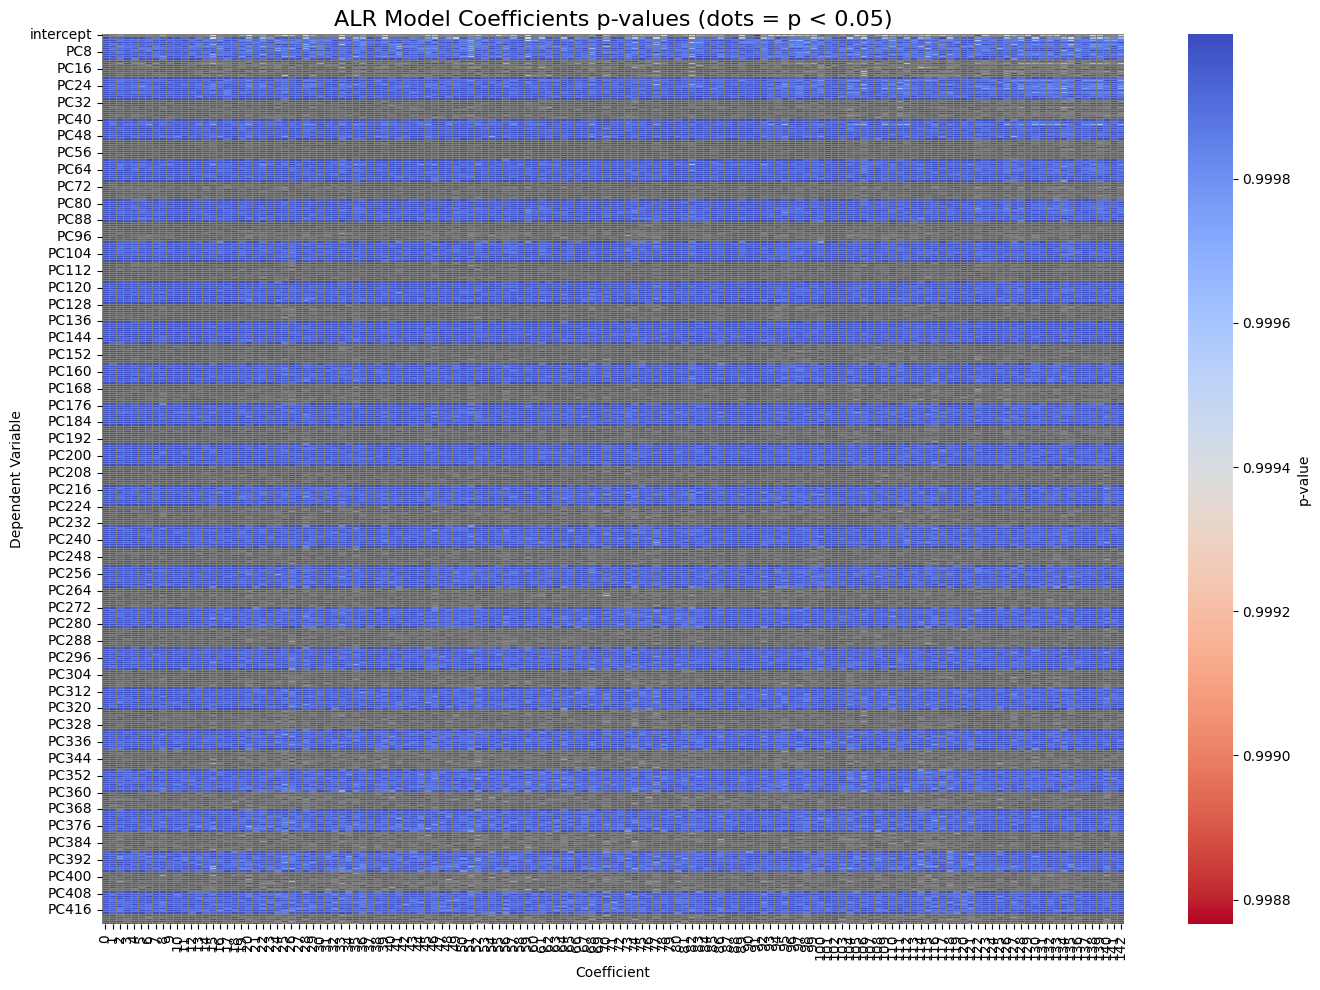

In [15]:
import seaborn as sns

pvals = alr_model.model.pvalues

plt.figure(figsize=(14, 10))
ax = sns.heatmap(pvals,cmap="coolwarm_r",linewidths=0.5,linecolor='gray',cbar_kws={'label': 'p-value'})

# Add black dots for significant coefficients
for i in range(pvals.shape[0]):
    for j in range(pvals.shape[1]):
        if pvals.iloc[i, j] < 0.05:
            plt.scatter(j + 0.5, i + 0.5, color='black', s=12.5, marker='o')  # s is size

nTT = int(waveClusters_and_pcs['kma_bmus'].nunique())  # 81
cluster_labels = np.arange(0, nTT-1)  # clusters 1..80, baseline = 81
ax.set_xticks(np.arange(pvals.shape[1]) + 0.5)
ax.set_xticklabels(cluster_labels, rotation=90)
plt.title("ALR Model Coefficients p-values (dots = p < 0.05)", fontsize=16)
plt.ylabel("Dependent Variable")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

#### Emulate Historical Hindcast (1980 - 2023)

In [16]:
pcs_per_sim_list = pd.read_csv(
    '../03A_Stochastic_GCMs_NC/outputs/cmip6_models/ipsl_cm6a_lr/ssp245/mslp_ipsl_cm6a_lr_ssp245_pcs_95.csv',
    index_col=0,
    parse_dates=True
)
pcs_per_sim_list.index = pd.to_datetime(pcs_per_sim_list.index).floor('D')

In [17]:
# Support both: list of DataFrames or single DataFrame
if isinstance(pcs_per_sim_list, pd.DataFrame):
    first_df = pcs_per_sim_list
    pcs_per_sim_list = [pcs_per_sim_list]
else:
    first_df = pcs_per_sim_list[0]

time = first_df.index
cov_names = first_df.columns
n_cov = len(cov_names)
n_sims = len(pcs_per_sim_list)

cov_stack = np.stack([df.values for df in pcs_per_sim_list])

covar_sim = xr.Dataset(
    data_vars=dict(
        cov_values=(("n_sim", "time", "n_covariates"), cov_stack),
        cov_names=(("n_sim", "n_covariates"),
                   np.tile(cov_names.values, (n_sims, 1)))
    ),
    coords=dict(
        n_sim=np.arange(n_sims),
        time=time,
        n_covariates=np.arange(n_cov),
    )
)

In [18]:
covar_sim

<xarray.Dataset> Size: 106MB
Dimensions:       (n_sim: 1, time: 31381, n_covariates: 422)
Coordinates:
  * n_sim         (n_sim) int64 8B 0
  * time          (time) datetime64[us] 251kB 2015-01-31 ... 2100-12-31
  * n_covariates  (n_covariates) int64 3kB 0 1 2 3 4 5 ... 417 418 419 420 421
Data variables:
    cov_values    (n_sim, time, n_covariates) float64 106MB -63.72 ... -1.715
    cov_names     (n_sim, n_covariates) object 3kB 'PC1' 'PC2' ... 'PC422'

In [19]:
print("covar_sim dims:", covar_sim.dims)
print("covar_sim.sizes:", covar_sim.sizes)
ds_i = covar_sim.isel(n_sim=0)
print("ds_i.cov_values.shape:", ds_i.cov_values.shape)   # (T_cov, n_cov)
print("time_sim length:", len(covar_sim.time.values))

covar_sim dims: FrozenMappingWarningOnValuesAccess({'n_sim': 1, 'time': 31381, 'n_covariates': 422})
covar_sim.sizes: Frozen({'n_sim': 1, 'time': 31381, 'n_covariates': 422})
ds_i.cov_values.shape: (31381, 422)
time_sim length: 31381


In [20]:
n_sims = covar_sim.sizes['n_sim']  # or len(covar_sim.n_sim)

simulated_daily_bmus_list = []
for i in range(n_sims):
    simulated_daily_bmus = alr_model.Simulate(
        num_sims=1,
        time_sim=covar_sim.time.values,
        xds_covars_sim=covar_sim.isel(n_sim=i),
    )
    simulated_daily_bmus_list.append(simulated_daily_bmus)

simulated_daily_bmus = xr.concat(simulated_daily_bmus_list, dim="n_sim")

/nfs/home/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/teslakit/util/time_operations.py:54: UserWarning: no explicit representation of timezones available for np.datetime64
  ts = (dt64 - np.datetime64('1970-01-01T00:00:00Z')) / np.timedelta64(1, 's')


ALR model fit   : 1980-01-01 --- 2023-11-22
ALR model sim   : 2015-01-31 --- 2100-12-31

Launching 1 simulations...

Sim. Num. 001: 100%|██████████| 31381/31381 [01:47<00:00, 290.98it/s]



/nfs/home/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/teslakit/io/aux_nc.py:73: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dim_names = xds_data.dims.keys()
/nfs/home/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/teslakit/util/time_operations.py:54: UserWarning: no explicit representation of timezones available for np.datetime64
  ts = (dt64 - np.datetime64('1970-01-01T00:00:00Z')) / np.timedelta64(1, 's')


In [21]:
sim = simulated_daily_bmus
print(sim.nan_days_per_sim.values)
print(sim.nan_pct_per_sim.values)
print(sim.attrs["nan_days_total"], sim.attrs["nan_days_total_pct"])

[0]
[0.]
0 0.0


Saving figures to: outputs/Figures/ALR/ipsl_245


/nfs/home/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/teslakit/util/time_operations.py:54: UserWarning: no explicit representation of timezones available for np.datetime64
  ts = (dt64 - np.datetime64('1970-01-01T00:00:00Z')) / np.timedelta64(1, 's')


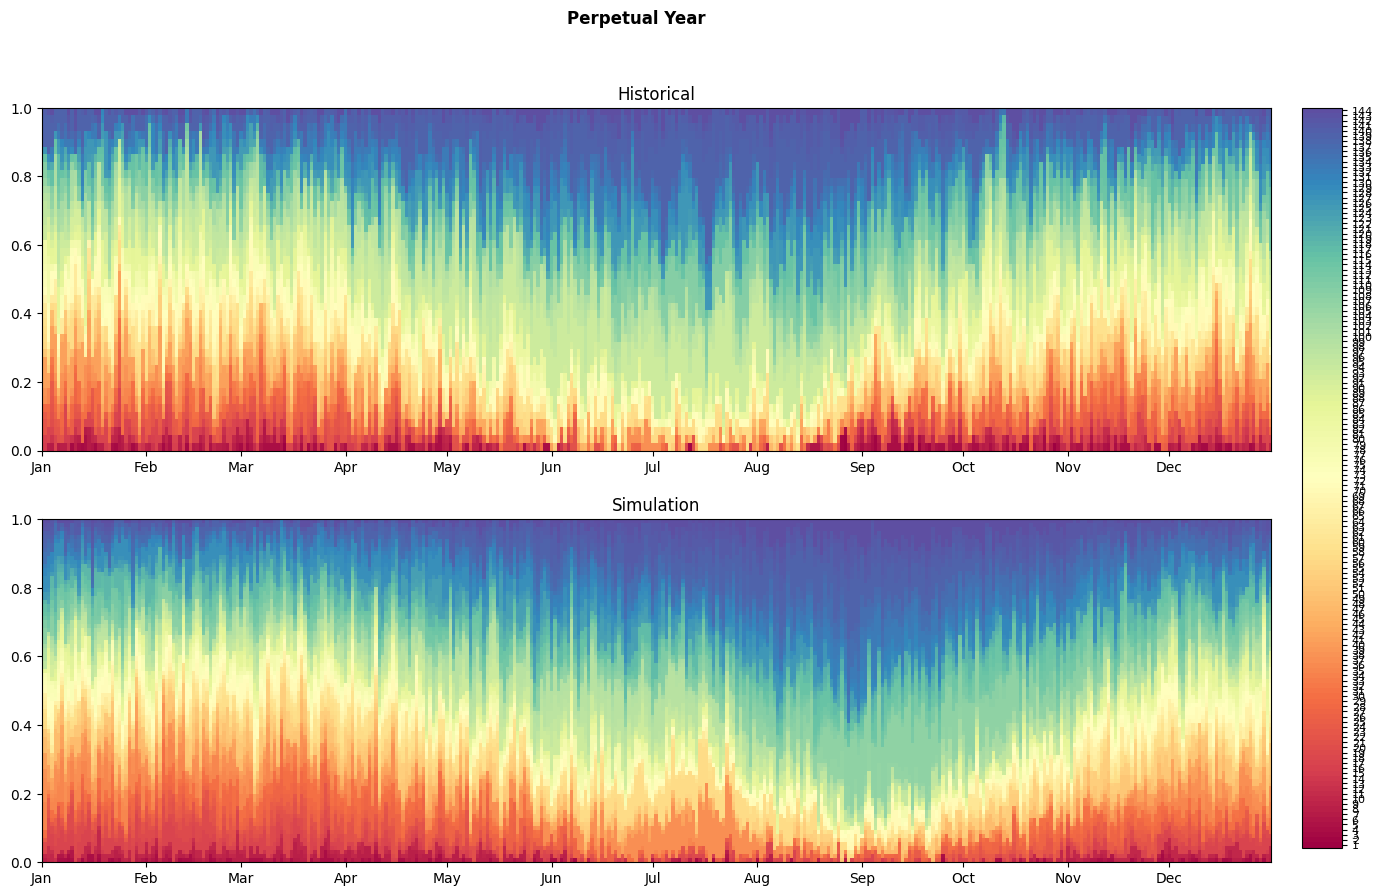

/nfs/home/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/teslakit/kma.py:65: RuntimeWarning: invalid value encountered in divide
  probs[ix,:] = count[ix,:] / np.sum(count[ix, :])


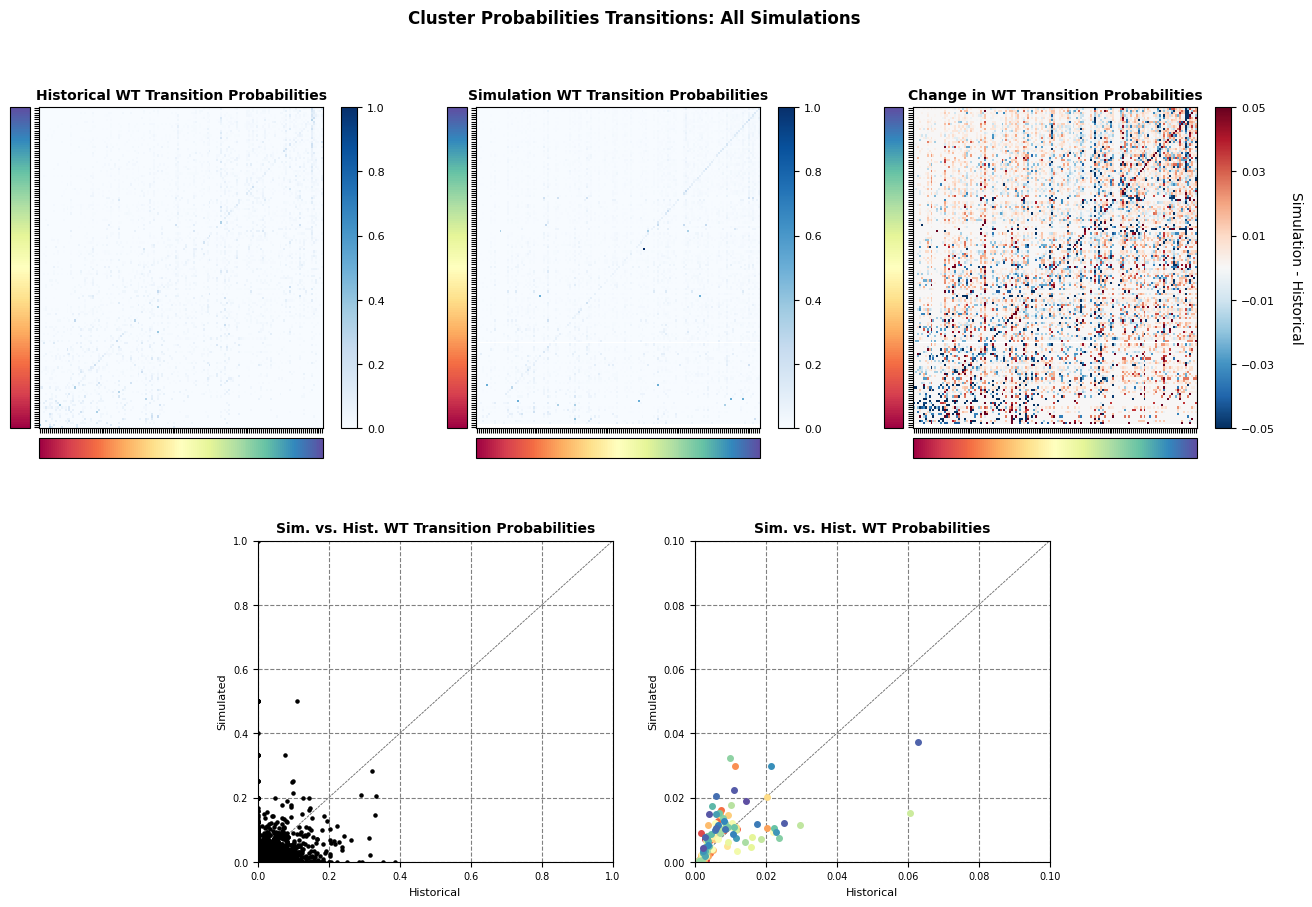

Saved 2 figures:
  outputs/Figures/ALR/ipsl_245/PerpetualYear.png
  outputs/Figures/ALR/ipsl_245/Transitions.png


[<Figure size 1585.64x980 with 3 Axes>, <Figure size 1585.64x980 with 14 Axes>]

In [22]:
# Save figures in project folder (works even if Jupyter was started elsewhere)
save_folder = os.path.join("outputs", "Figures", "ALR/ipsl_245")
os.makedirs(save_folder, exist_ok=True)
print("Saving figures to:", save_folder)

l_figs = alr_model.Report_Sim()

# Save all figures
fig_names = ["PerpetualYear.png", "Transitions.png", "Persistences.png"]
saved = []
for fig, name in zip(l_figs, fig_names):
    path = os.path.join(save_folder, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    saved.append(path)
print("Saved", len(saved), "figures:")
for p in saved:
    print(" ", p)

l_figs  # keep figures in notebook output

Saved: BMUS_Observed_vs_Simulated.png


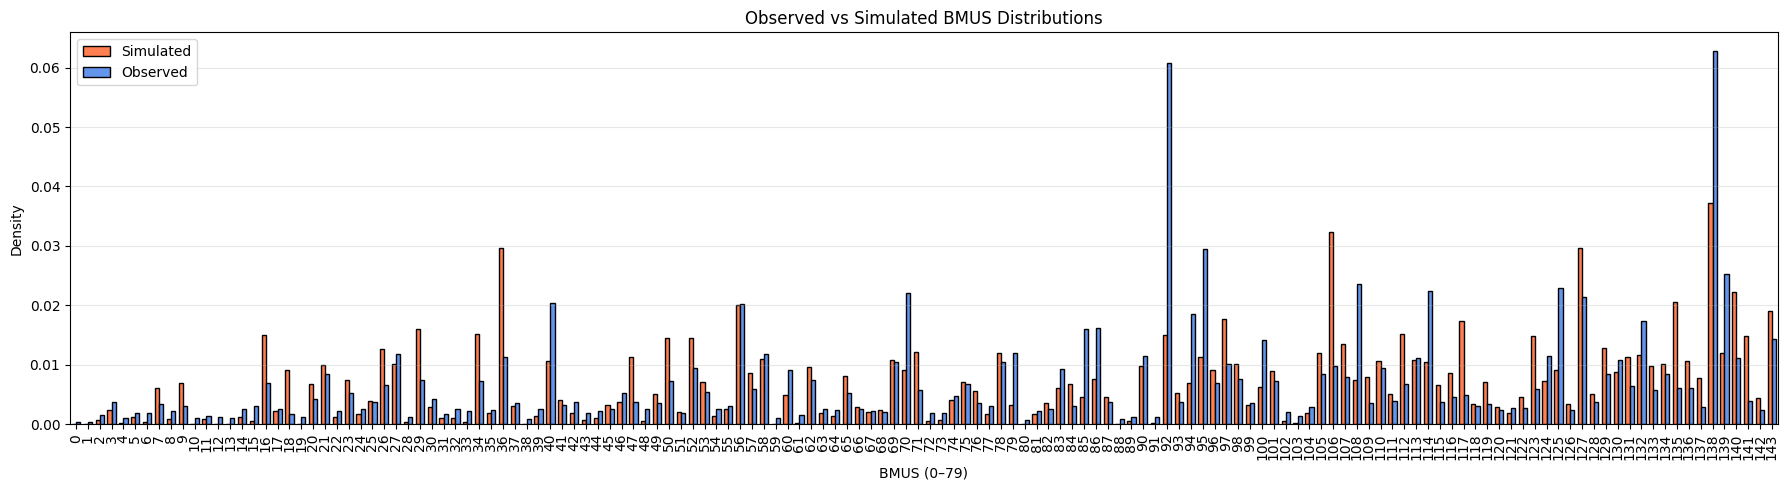

In [23]:
# Flatten simulated BMUs for comparison
sim_vals = simulated_daily_bmus.evbmus_sims.values.flatten()-1
fit_vals = xds_bmus_fit.bmus.values-1

bmus = np.arange(0,nTT,1)

# Compute densities (or frequencies)
sim_counts = [np.mean(sim_vals == bmu) for bmu in bmus]
fit_counts = [np.mean(fit_vals == bmu) for bmu in bmus]

# Width for bars
width = 0.35
x = np.arange(len(bmus))

plt.figure(figsize=(18,5))
plt.bar(x - width/2, sim_counts, width, label='Simulated', color='coral', edgecolor='black')
plt.bar(x + width/2, fit_counts, width, label='Observed', color='cornflowerblue', edgecolor='black')

# label only every 5th BMU and rotate labels
step = 1
plt.xticks(x[::step], bmus[::step], rotation=90)

plt.xlim(-0.5, len(bmus) - 0.5)
plt.xlabel('BMUS (0–79)')
plt.ylabel('Density')
plt.title('Observed vs Simulated BMUS Distributions')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
# Save figure
import os
save_folder = os.path.join("outputs", "Figures", "ALR/ipsl_245")
os.makedirs(save_folder, exist_ok=True)
plt.gcf().savefig(os.path.join(save_folder, "BMUS_Observed_vs_Simulated.png"), dpi=150, bbox_inches="tight")
print("Saved: BMUS_Observed_vs_Simulated.png")
plt.show()

#### Time-series Emulated - Using Random Cluster data from Binwaves Simulation

In [24]:
import importlib
import os
import utils.bmu_bootstrap_timeseries as bmu_bt
importlib.reload(bmu_bt)
from utils.bmu_bootstrap_timeseries import create_bmu_bootstrap_waves_winds_for_merged_sites

# ---------------------------------------------------------------------------
# Hindcast product: choose one
#   "merged_grids" → full BinWaves merge (includes offshore / fewPoints coords)
#   "500m"         → coastal 500 m points only
# ---------------------------------------------------------------------------
product = "merged_grids"  # "merged_grids" | "500m"

PRODUCTS = {
    "merged_grids": {
        "source_dir": "../02_Wind_Metamodel/outputs/NorthCarolina",
        "output_dir": "outputs/ipsl_245/OffshorePoints",
    },
    # "500m": {
    #     "source_dir": "outputs/merged_500m_binwaves_bmus",
    #     # or: "../02_Wind_Metamodel/outputs/merged_500m_binwaves_bmus"
    #     "output_dir": "outputs/ipsl_245/OffshorePoints",
    # },
}
if product not in PRODUCTS:
    raise ValueError(f"Unknown product={product!r}. Choose one of {list(PRODUCTS)}")

source_dir = PRODUCTS[product]["source_dir"]
output_dir = PRODUCTS[product]["output_dir"]
print(f"product={product}\nsource_dir={source_dir}\noutput_dir={output_dir}")

available_variables = sorted({
    os.path.splitext(fn)[0].split("_", 1)[0]
    for fn in os.listdir(source_dir)
    if fn.endswith(".nc")
})
selected_variables = available_variables

# Site selection (pick one):
# - None  → all sites in source_dir files
# - one point: selected_coordinate=(36.1942, -75.7316)
# - several points: selected_coordinate=[(lat, lon), ...]  (nearest site each; duplicates dropped)
# - or by index: selected_site_indices=[12, 45, 90]
selected_coordinate = [
    (36.400, -75.200),
    (36.300, -75.400),
    (36.258, -75.593),
    (36.187500, -74.875000),
    (35.625000, -74.875000),
    (35.375000, -75.187500),
    (34.812500, -75.812500),
    (34.125000, -77.000000),
    (33.375000, -78.375000),
]

selection = create_bmu_bootstrap_waves_winds_for_merged_sites(
    hindcast_waves_winds_dir=source_dir,
    simulated_daily_bmus=simulated_daily_bmus,
    waveclusters_and_pcs=waveClusters_and_pcs,
    output_dir=output_dir,
    monthly_conditioning=True,
    skip_existing_outputs=True,
    sim_indices=0,
    n_workers=6,  # parallel files (~5 GB RAM per worker)
    selected_coordinate=selected_coordinate,
)


product=merged_grids
source_dir=../02_Wind_Metamodel/outputs/NorthCarolina
output_dir=outputs/ipsl_245/OffshorePoints


BMU bootstrap:   0%|          | 0/23 [00:00<?, ?file/s]

[Duck_bulk_parameters_4points.nc] Loading to RAM and resampling to 1D means for 2 sites.
[dp0_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[dp2_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[dp1_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[dm_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[Duck_partitions_4points.nc] Loading to RAM and resampling to 1D means for 2 sites.
[dp3_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[dp_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[hs_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[phs0_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[phs1_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[phs2_NorthCarolina.nc] Loading to RAM and resampling to 1D means for 9 sites.
[phs3_NorthCarolina.nc] Loading to RAM and resa

HS: hs_NorthCarolina.nc | target (36.1942, -75.7316) -> nearest site 1670 (36.2580, -75.5930), distance=14.314 km
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Location_map_selected_site.png


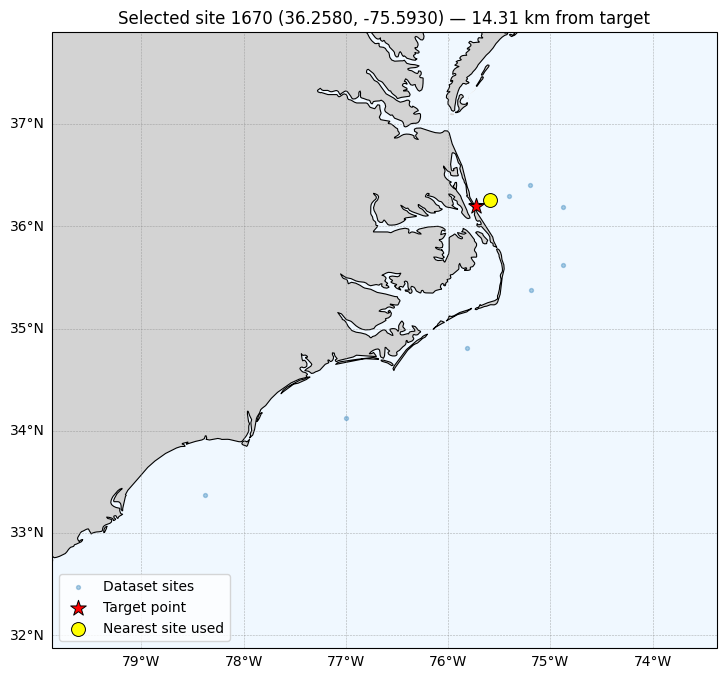

Historical folder: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/02_Wind_Metamodel/outputs/NorthCarolina
  historical via src_index=1670 (hs_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_hs_Historical_vs_Simulated.png


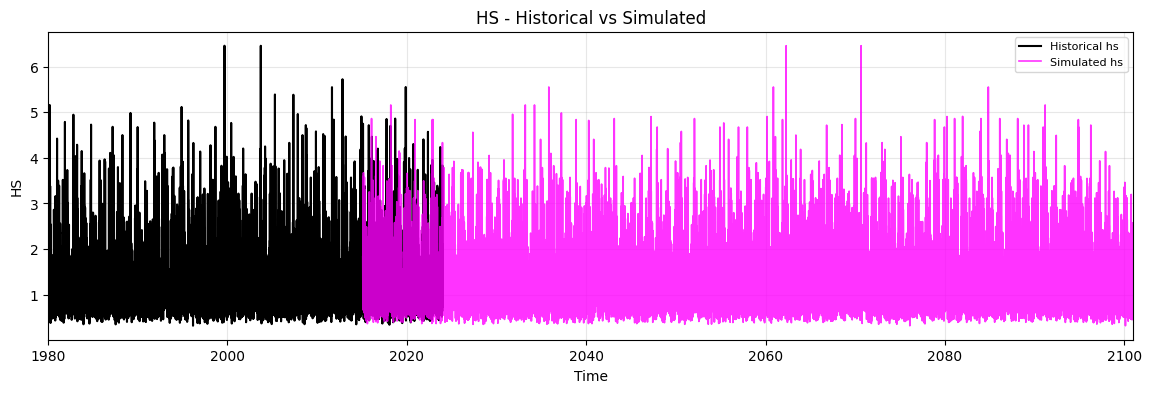

TP: tp_NorthCarolina.nc | target (36.1942, -75.7316) -> nearest site 1670 (36.2580, -75.5930), distance=14.314 km
  historical via src_index=1670 (tp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_tp_Historical_vs_Simulated.png


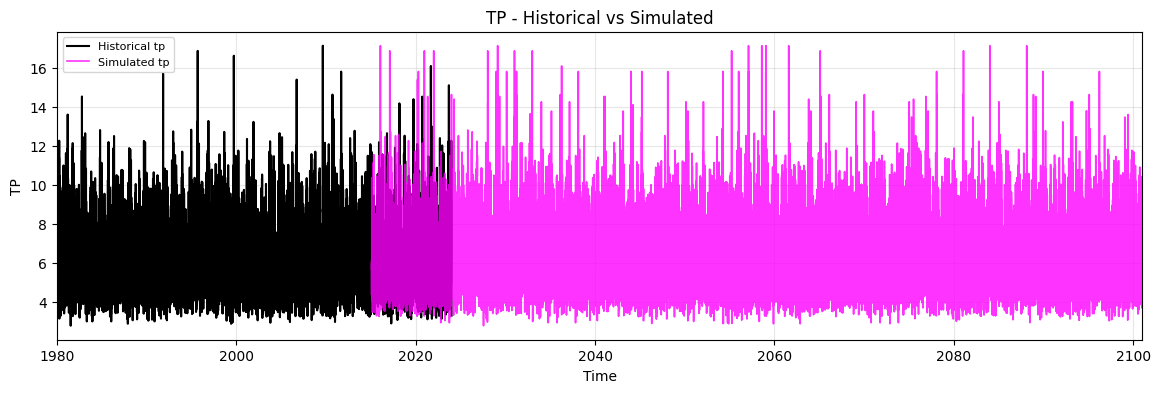

DP: dp_NorthCarolina.nc | target (36.1942, -75.7316) -> nearest site 1670 (36.2580, -75.5930), distance=14.314 km
  historical via src_index=1670 (dp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_dp_Historical_vs_Simulated.png


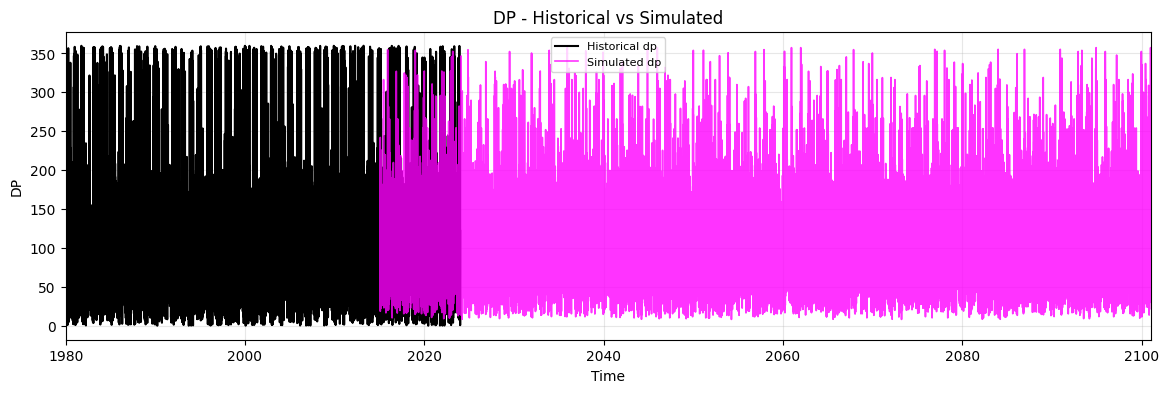

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Histograms_allvars_bulk_random_member.png


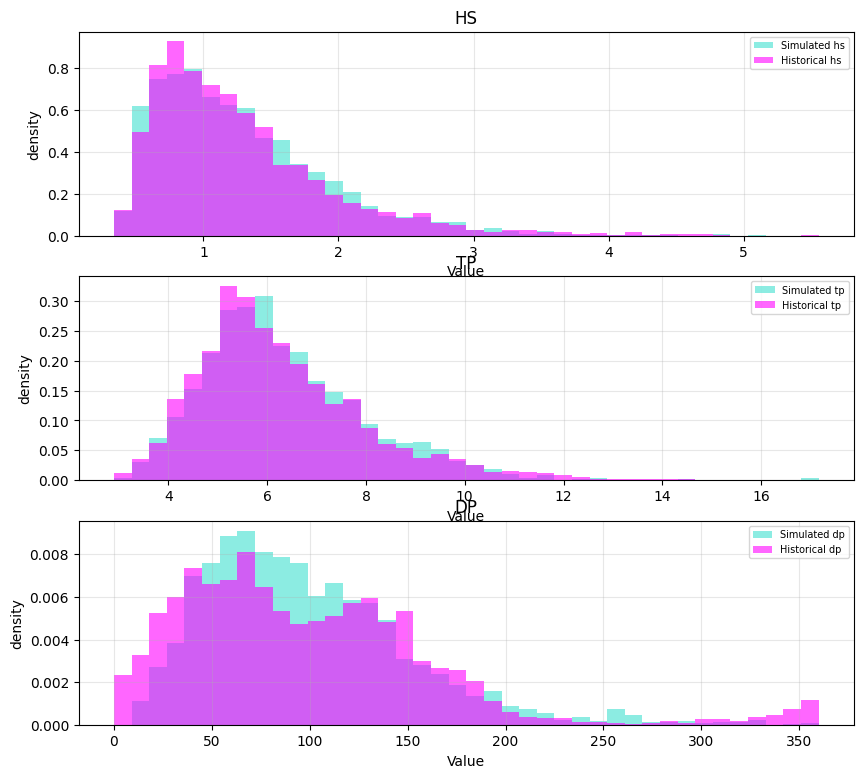

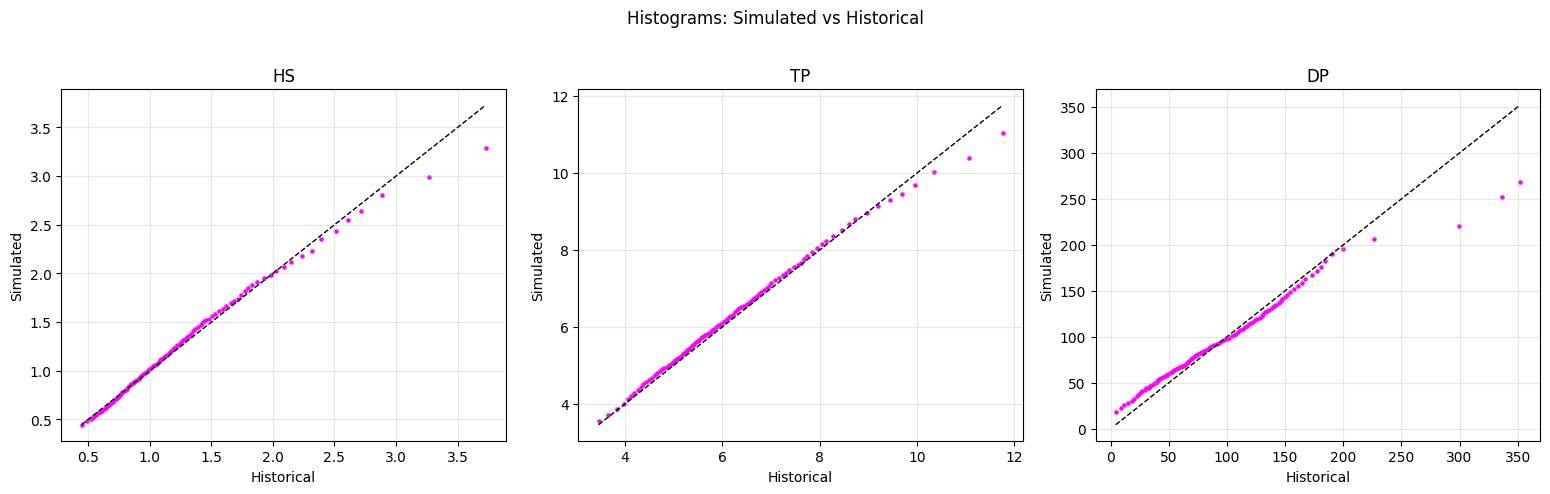

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/QQ_allvars_Historical_vs_Simulated.png


<Figure size 640x480 with 0 Axes>

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_hs_bulk.png


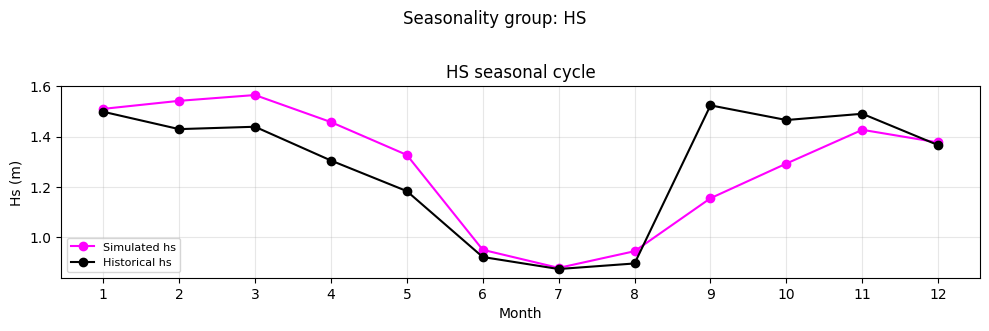

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_tp_bulk.png


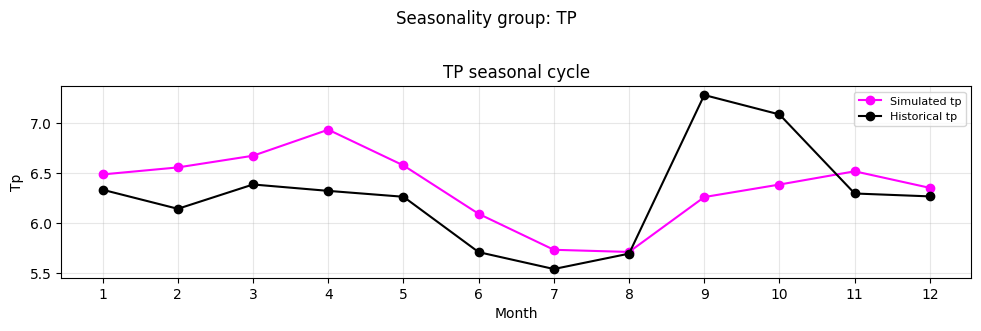

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_dp_bulk.png


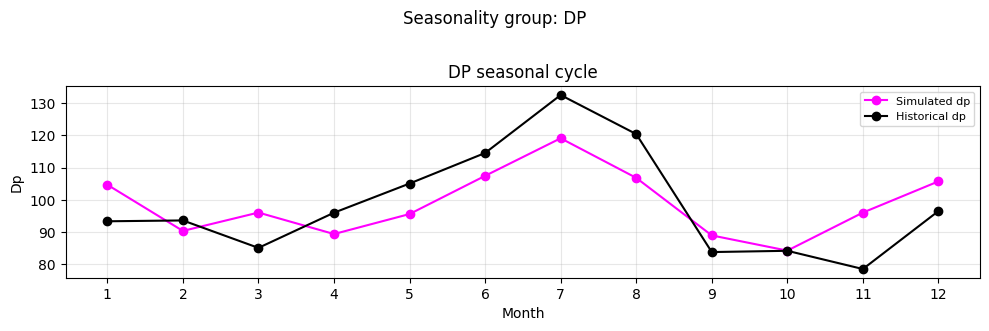

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Scatter_group_level_base_Historical_vs_Simulated_overlap.png


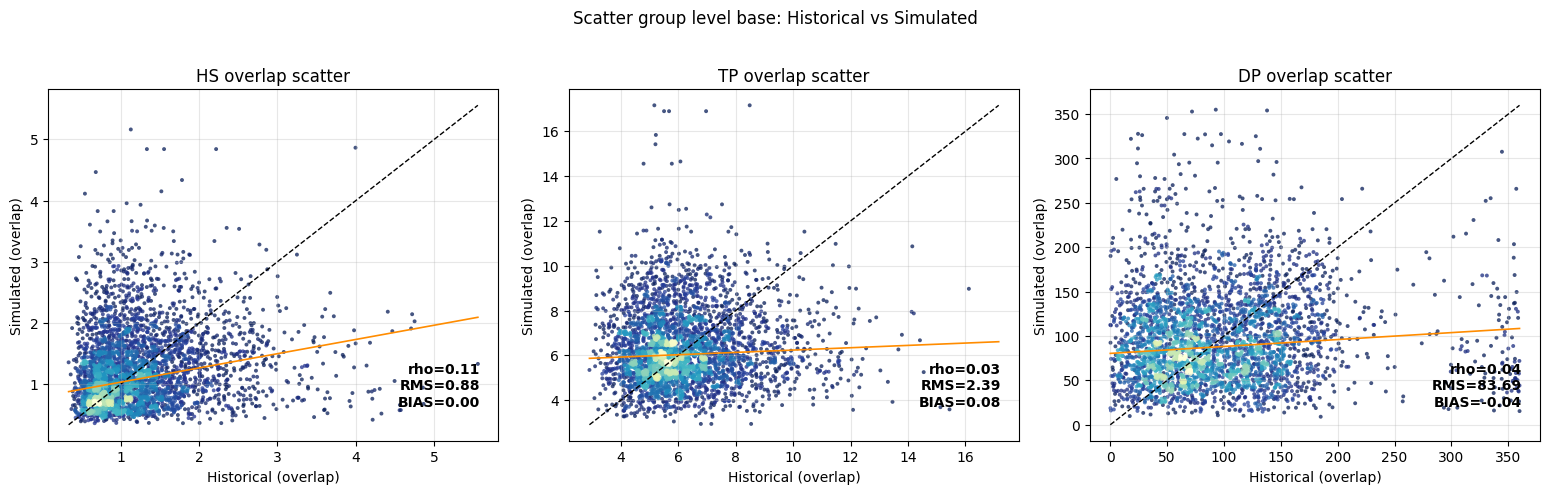

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_timeseries_bulk_vs_emulator.png


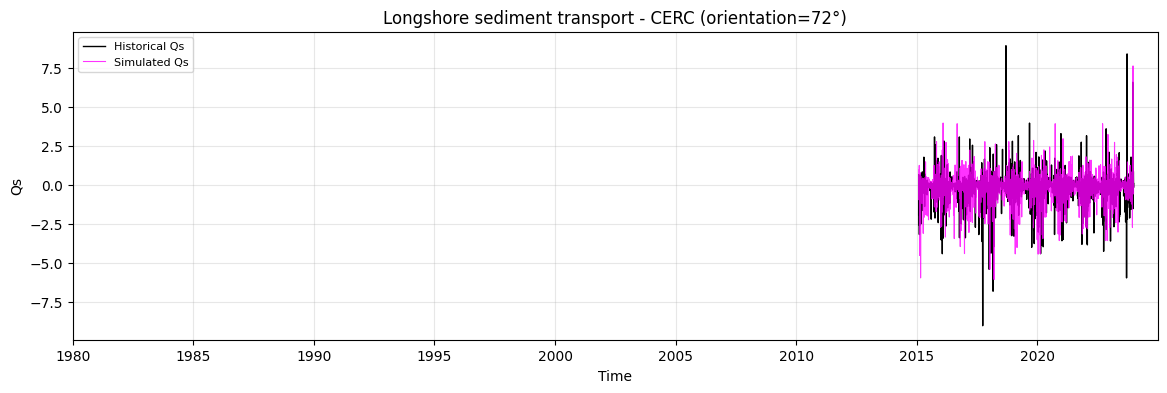

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_cumulative_bulk_vs_emulator.png


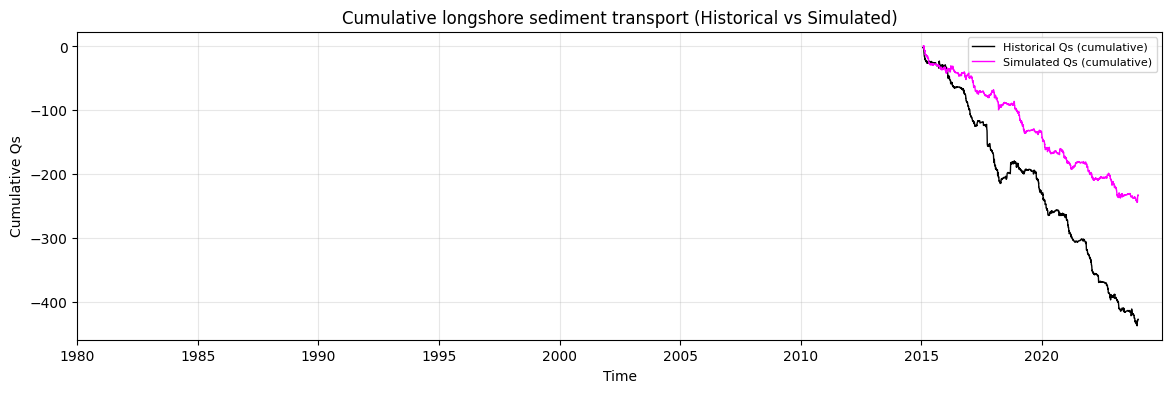

In [25]:
import importlib
importlib.reload(alr_plotting)
daily_pairs, save_folder = alr_plotting.plot_from_folder(
    data_folder="outputs/ipsl_245/OffshorePoints",
    point_lat=36.1942,
    point_lon=-75.7316,
    variables=["hs", "tp", "dp"],
    historical_folder="../02_Wind_Metamodel/outputs/NorthCarolina",
    shoreline_orientation_deg=72,
    original_band=None,
    plot_non_overlap_timeseries=True,
)


HS: hs_NorthCarolina.nc | target (33.8883, -78.1551) -> nearest site 696 (33.3750, -78.3750), distance=60.599 km
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Location_map_selected_site.png


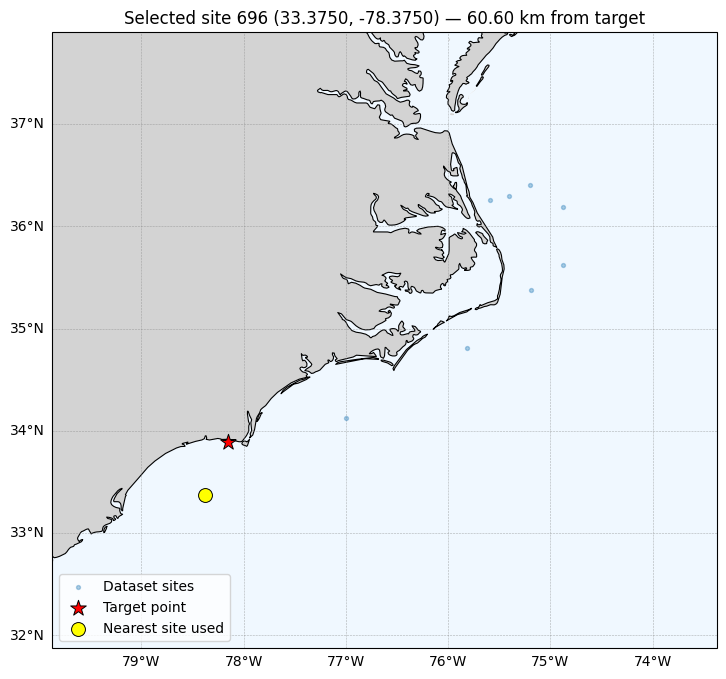

Historical folder: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/02_Wind_Metamodel/outputs/NorthCarolina
  historical via src_index=696 (hs_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_hs_Historical_vs_Simulated.png


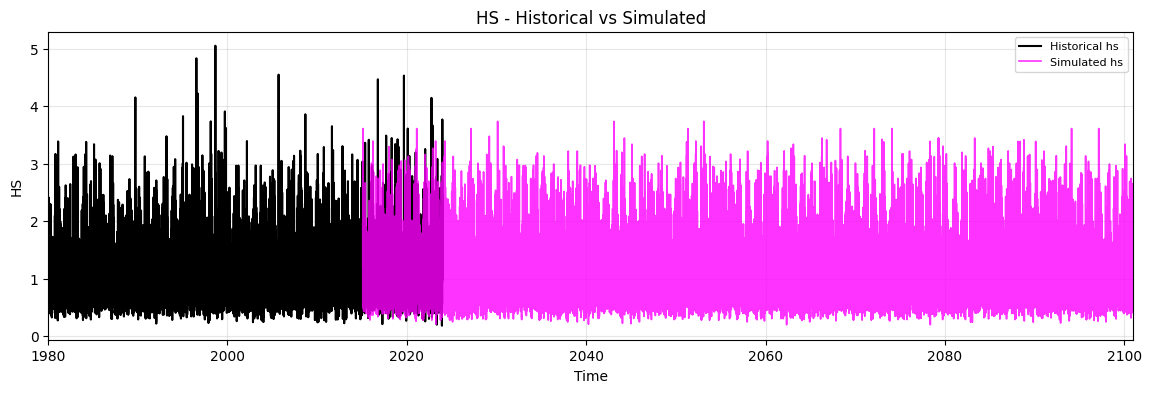

TP: tp_NorthCarolina.nc | target (33.8883, -78.1551) -> nearest site 696 (33.3750, -78.3750), distance=60.599 km
  historical via src_index=696 (tp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_tp_Historical_vs_Simulated.png


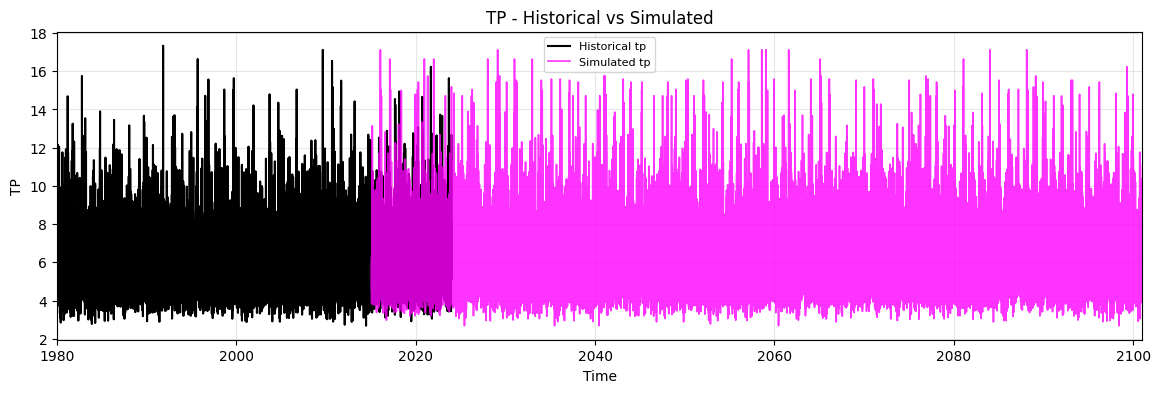

DP: dp_NorthCarolina.nc | target (33.8883, -78.1551) -> nearest site 696 (33.3750, -78.3750), distance=60.599 km
  historical via src_index=696 (dp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_dp_Historical_vs_Simulated.png


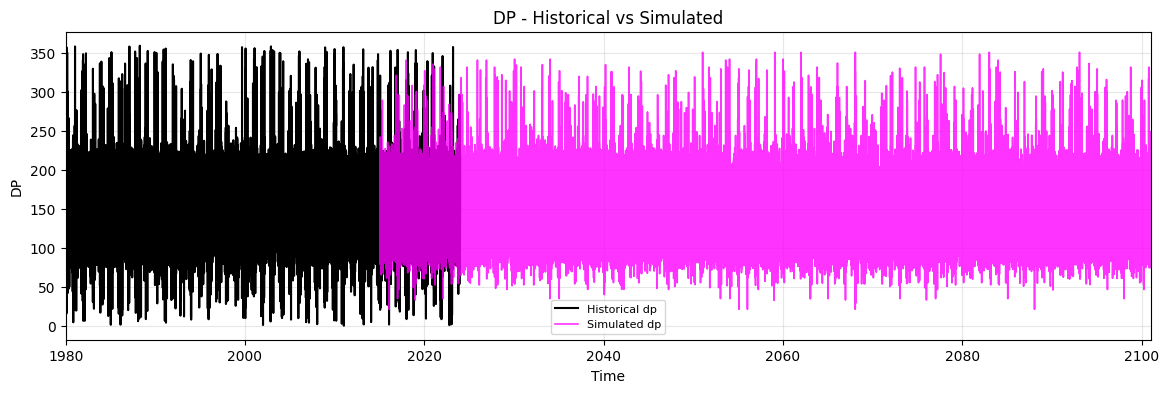

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Histograms_allvars_bulk_random_member.png


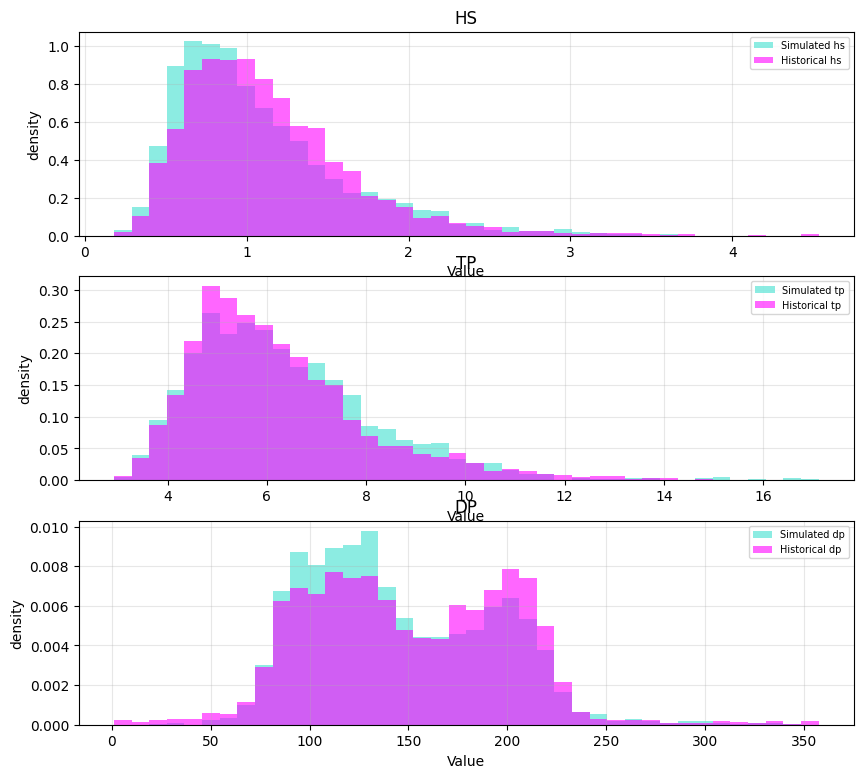

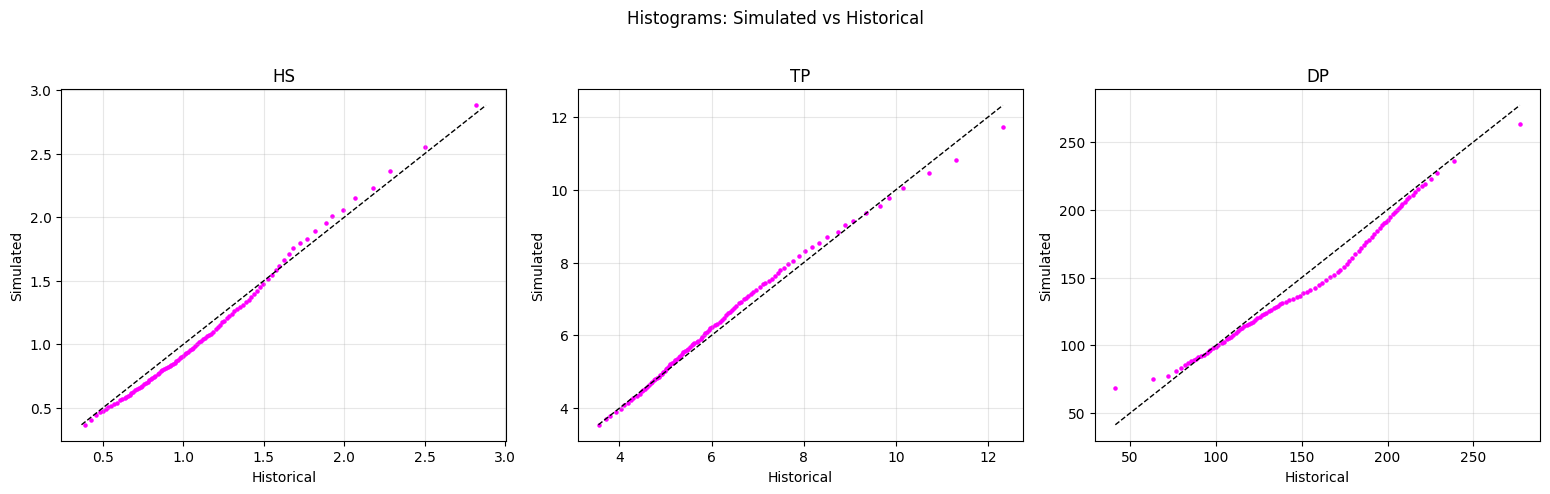

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/QQ_allvars_Historical_vs_Simulated.png


<Figure size 640x480 with 0 Axes>

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_hs_bulk.png


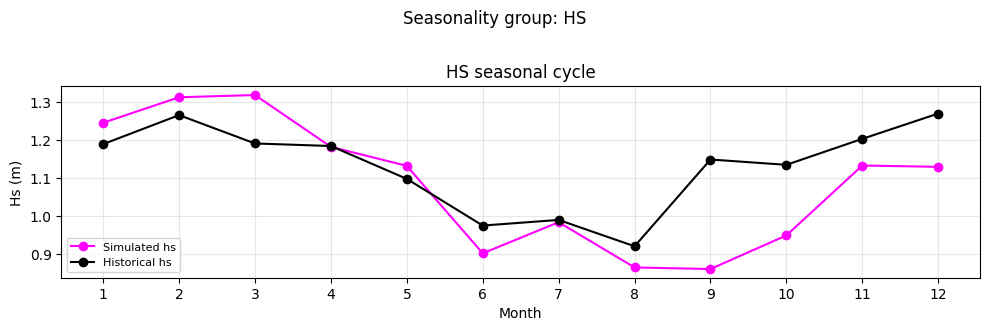

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_tp_bulk.png


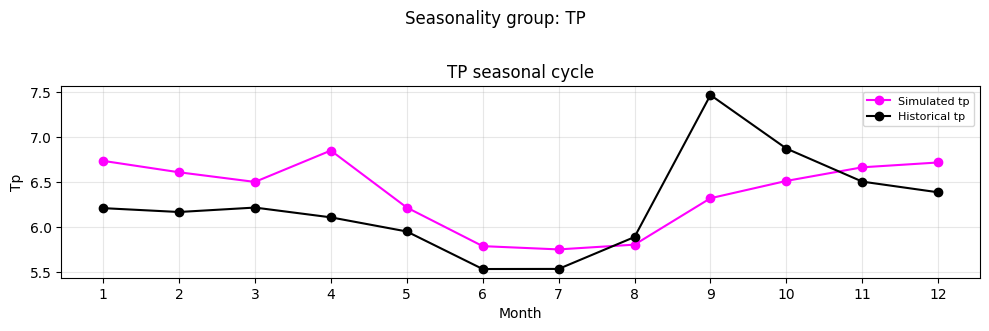

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_dp_bulk.png


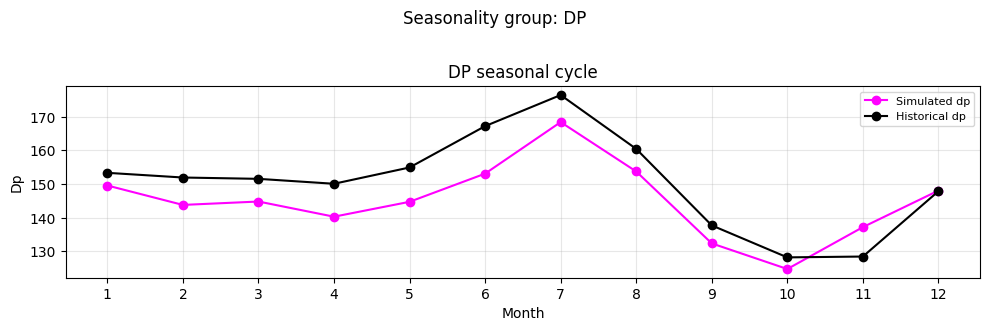

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Scatter_group_level_base_Historical_vs_Simulated_overlap.png


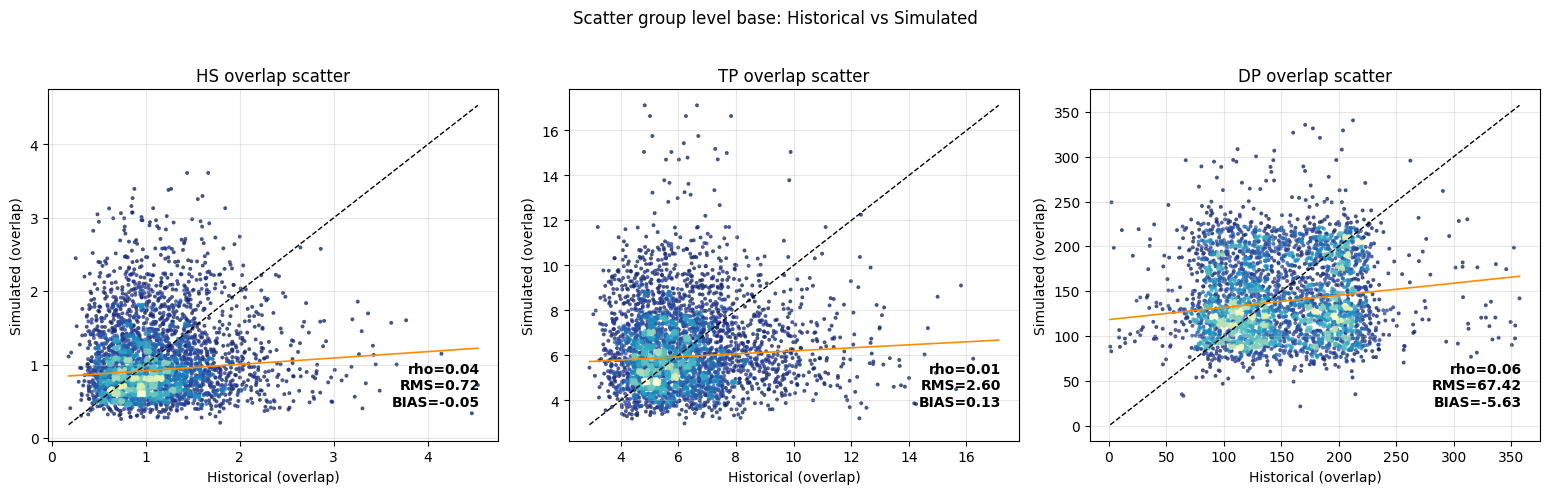

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_timeseries_bulk_vs_emulator.png


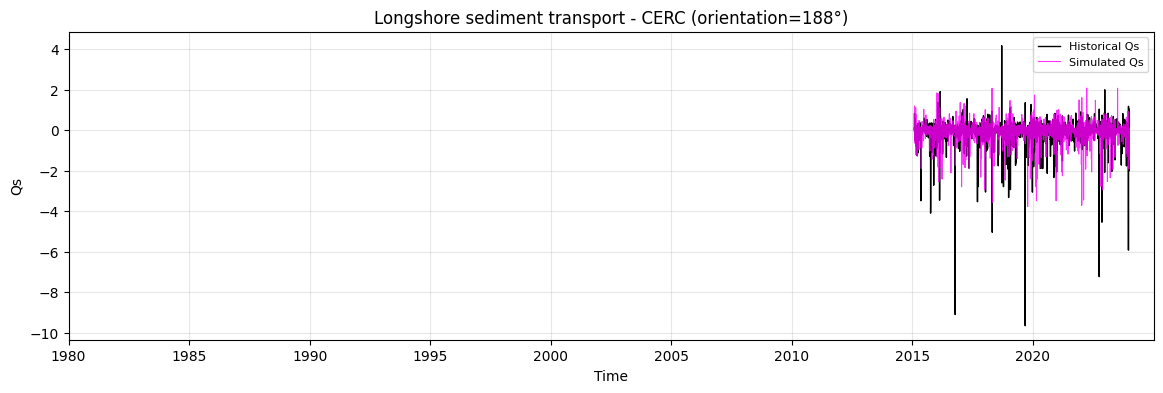

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_cumulative_bulk_vs_emulator.png


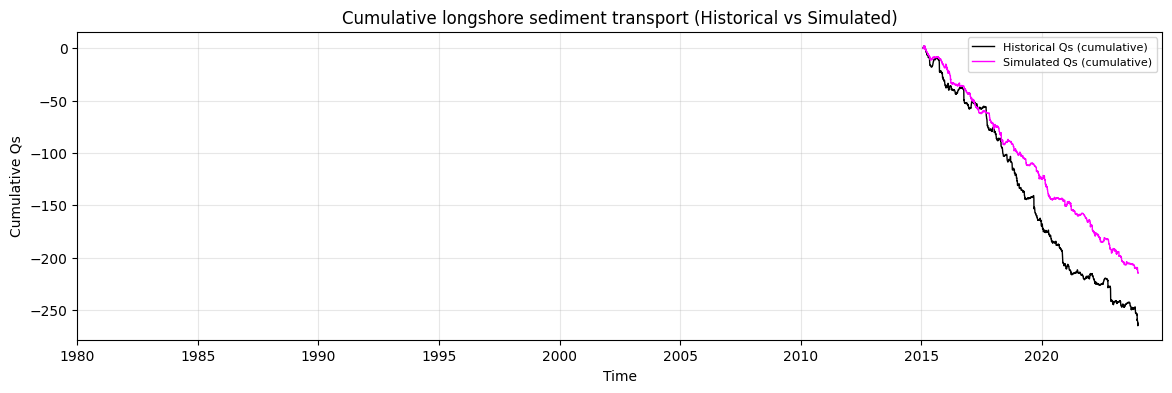

In [26]:
import importlib
importlib.reload(alr_plotting)
daily_pairs, save_folder = alr_plotting.plot_from_folder(
    data_folder="outputs/ipsl_245/OffshorePoints",
    point_lat=33.8883,
    point_lon=-78.1551,
    variables=["hs", "tp", "dp"],
    historical_folder="../02_Wind_Metamodel/outputs/NorthCarolina",
    shoreline_orientation_deg=188,
    original_band=None,
    plot_non_overlap_timeseries=True,
)


HS: hs_NorthCarolina.nc | target (36.1875, -74.8750) -> nearest site 3124 (36.1875, -74.8750), distance=0.000 km
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Location_map_selected_site.png


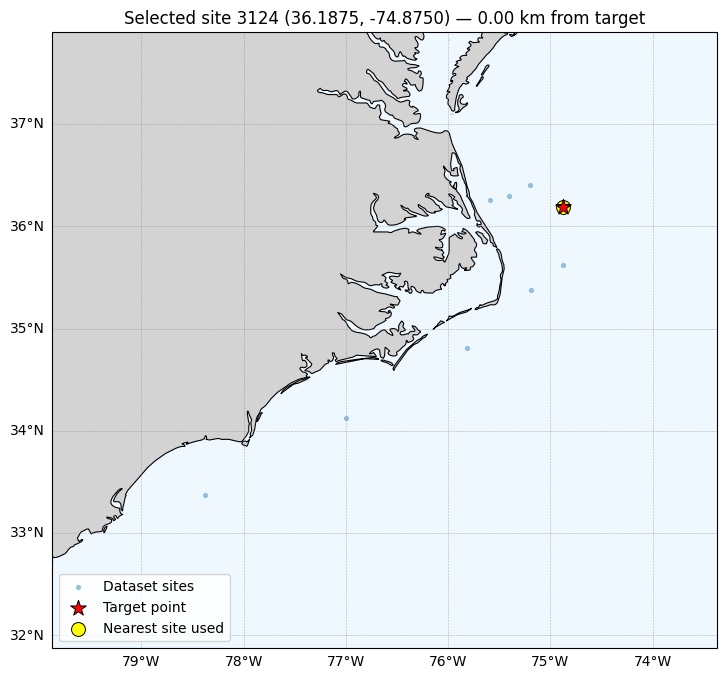

Historical folder: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/02_Wind_Metamodel/outputs/NorthCarolina
  historical via src_index=3124 (hs_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_hs_Historical_vs_Simulated.png


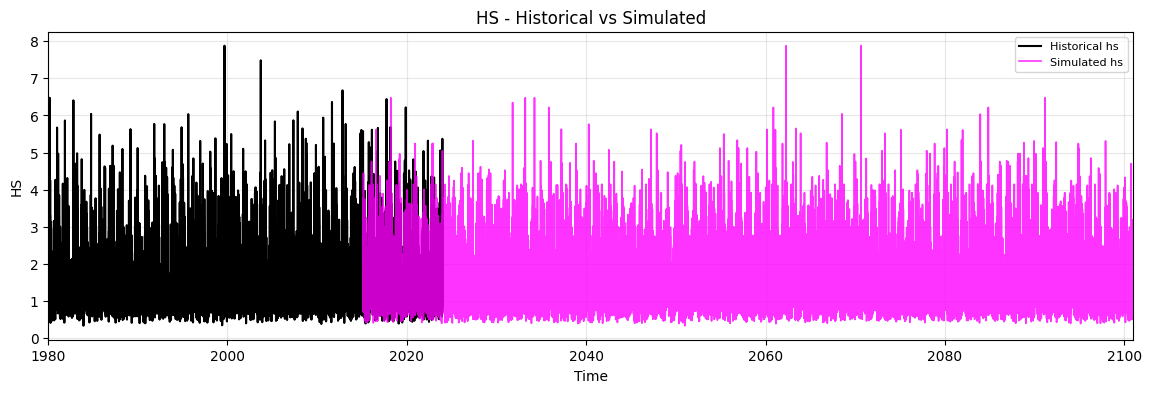

TP: tp_NorthCarolina.nc | target (36.1875, -74.8750) -> nearest site 3124 (36.1875, -74.8750), distance=0.000 km
  historical via src_index=3124 (tp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_tp_Historical_vs_Simulated.png


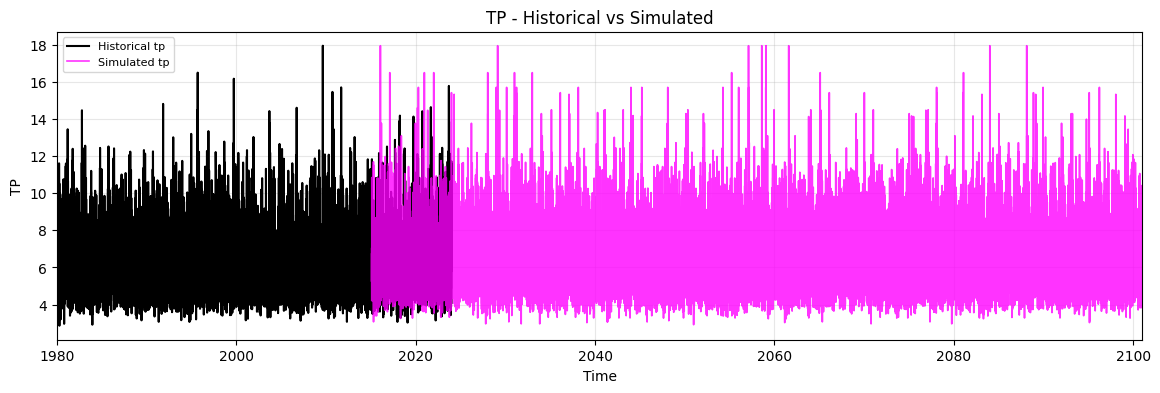

DP: dp_NorthCarolina.nc | target (36.1875, -74.8750) -> nearest site 3124 (36.1875, -74.8750), distance=0.000 km
  historical via src_index=3124 (dp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_dp_Historical_vs_Simulated.png


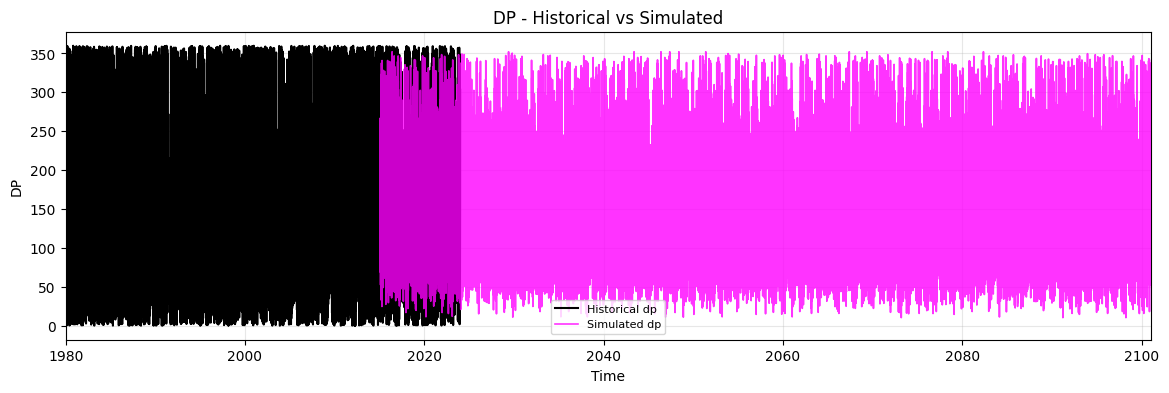

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Histograms_allvars_bulk_random_member.png


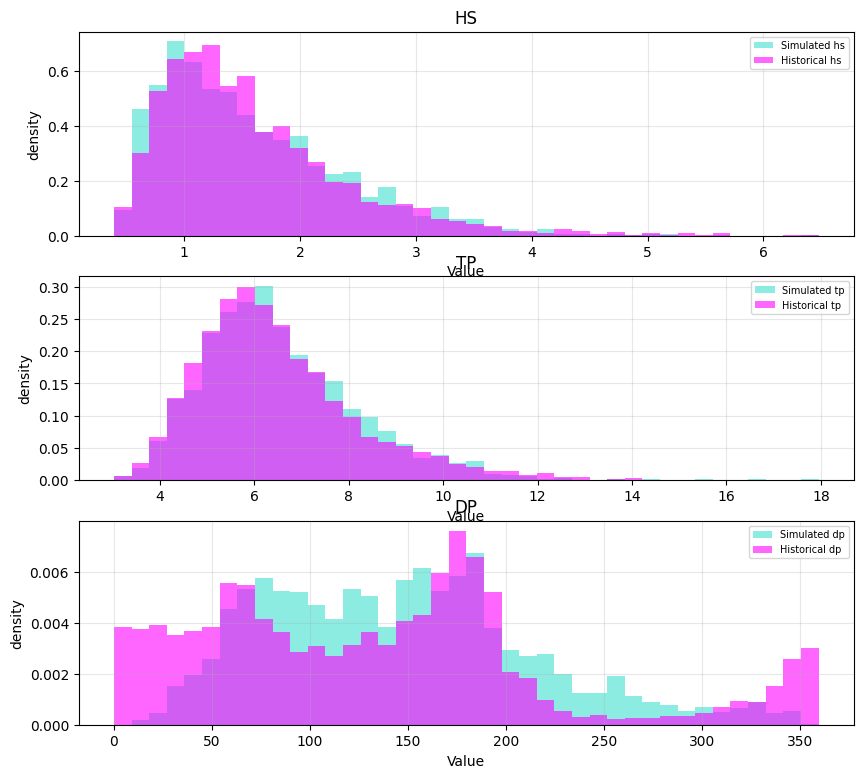

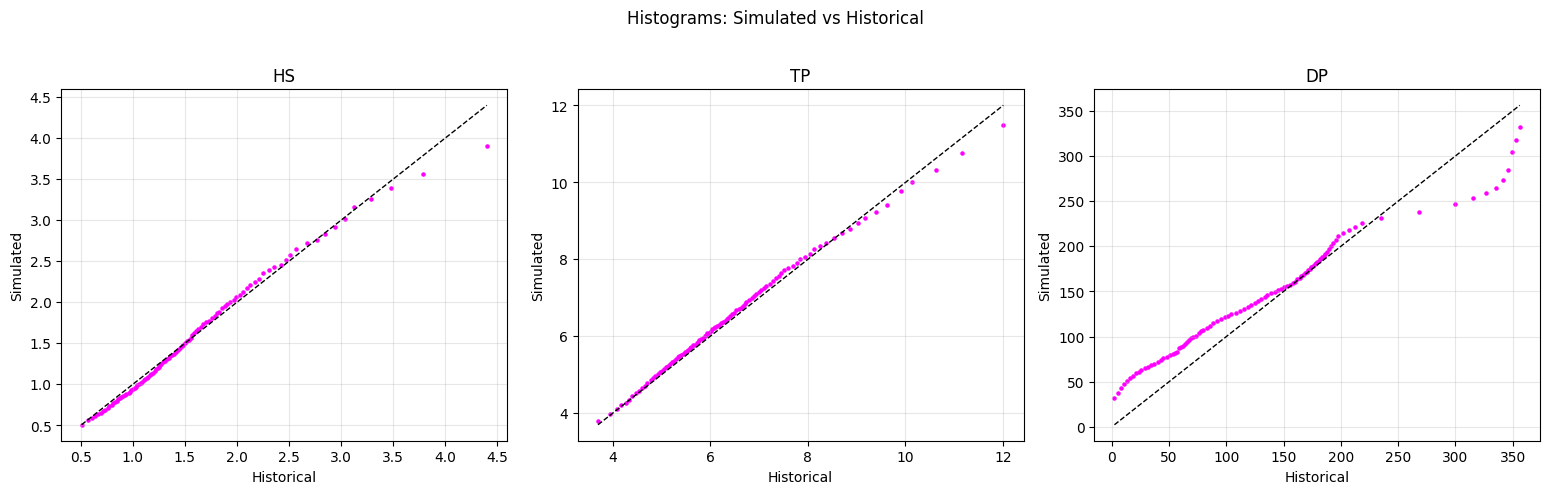

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/QQ_allvars_Historical_vs_Simulated.png


<Figure size 640x480 with 0 Axes>

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_hs_bulk.png


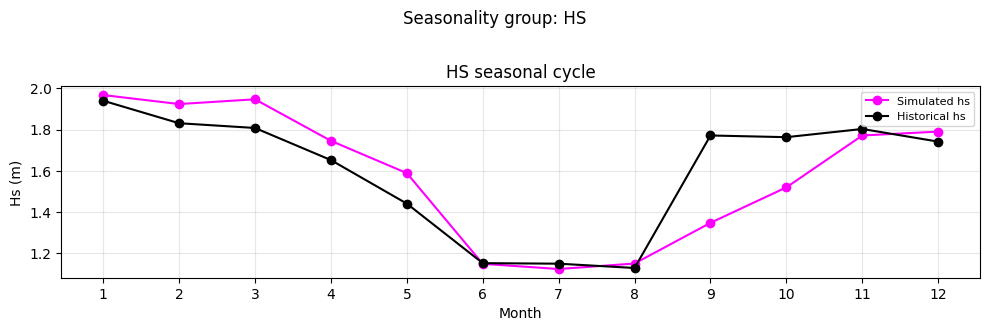

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_tp_bulk.png


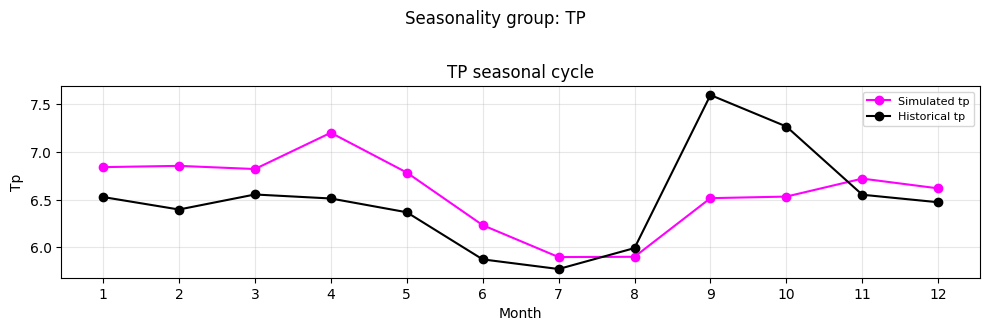

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_dp_bulk.png


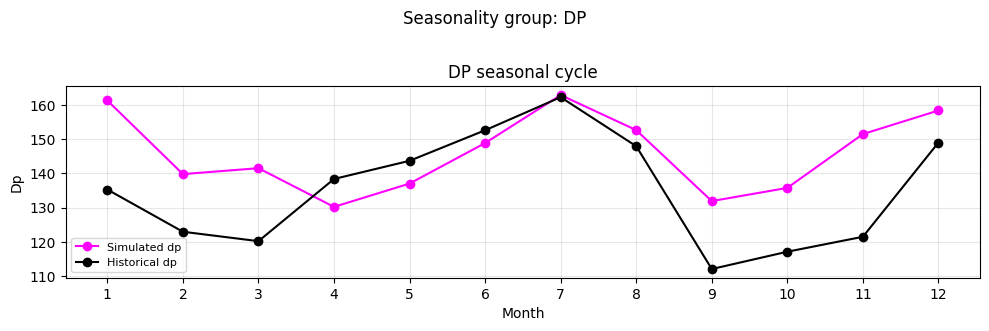

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Scatter_group_level_base_Historical_vs_Simulated_overlap.png


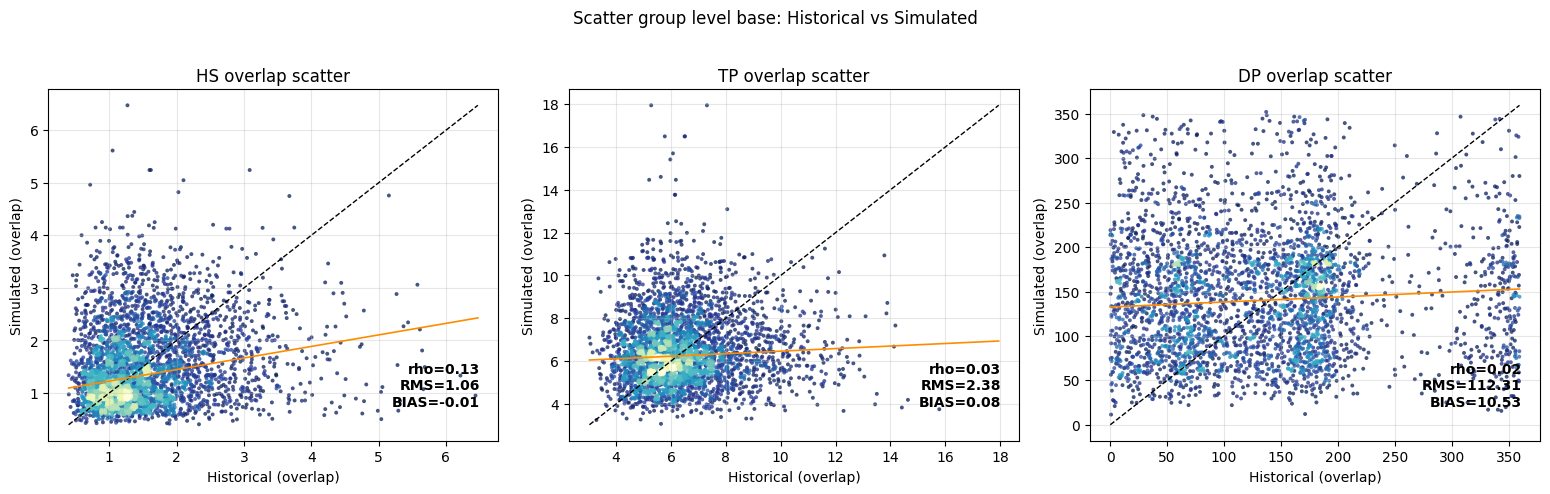

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_timeseries_bulk_vs_emulator.png


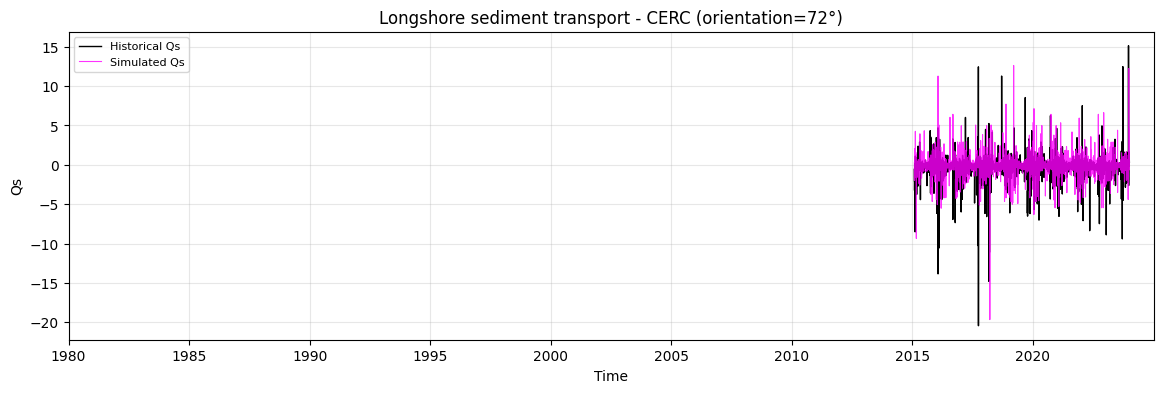

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_cumulative_bulk_vs_emulator.png


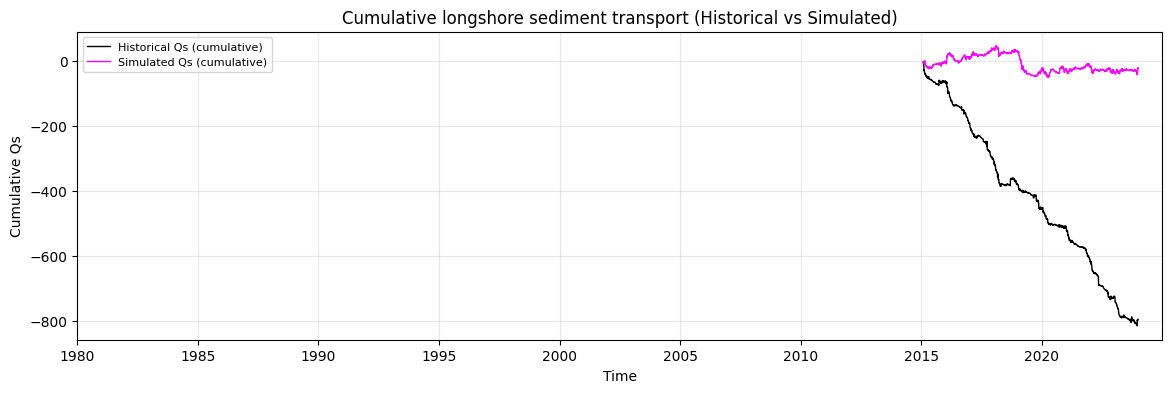

In [27]:
import importlib
importlib.reload(alr_plotting)
daily_pairs, save_folder = alr_plotting.plot_from_folder(
    data_folder="outputs/ipsl_245/OffshorePoints",
    point_lat=36.1875,
    point_lon=-74.875,
    variables=["hs", "tp", "dp"],
    historical_folder="../02_Wind_Metamodel/outputs/NorthCarolina",
    shoreline_orientation_deg=72,
    original_band=None,
    plot_non_overlap_timeseries=True,
)


HS: hs_NorthCarolina.nc | target (36.4000, -75.2000) -> nearest site 2964 (36.4000, -75.2000), distance=0.000 km
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Location_map_selected_site.png


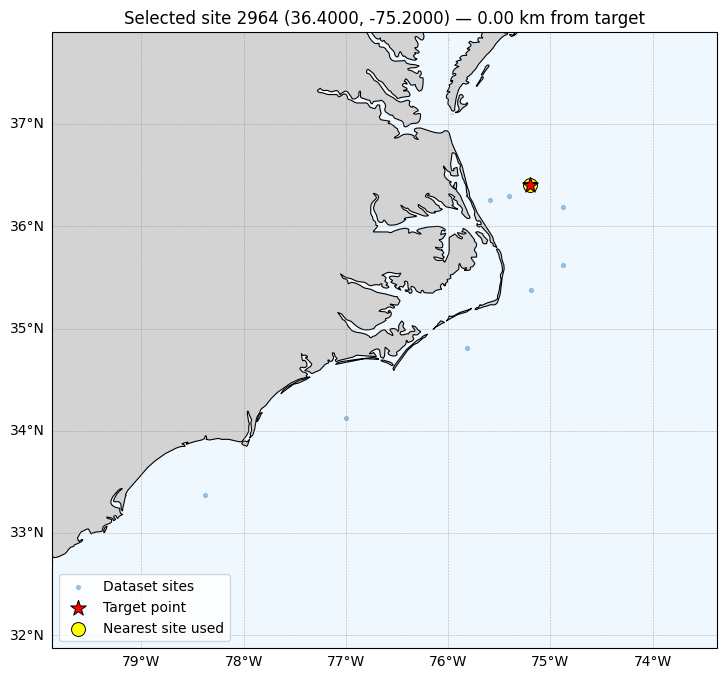

Historical folder: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/02_Wind_Metamodel/outputs/NorthCarolina
  historical via src_index=2964 (hs_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_hs_Historical_vs_Simulated.png


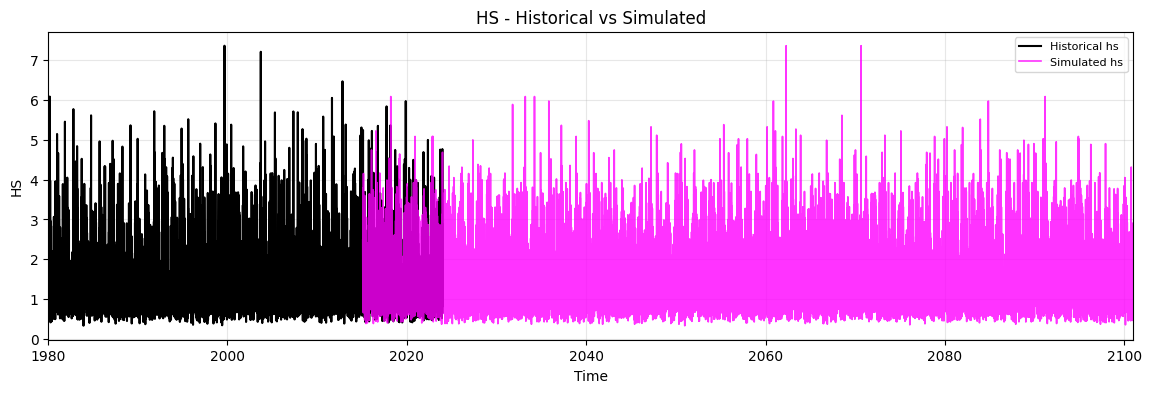

TP: tp_NorthCarolina.nc | target (36.4000, -75.2000) -> nearest site 2964 (36.4000, -75.2000), distance=0.000 km
  historical via src_index=2964 (tp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_tp_Historical_vs_Simulated.png


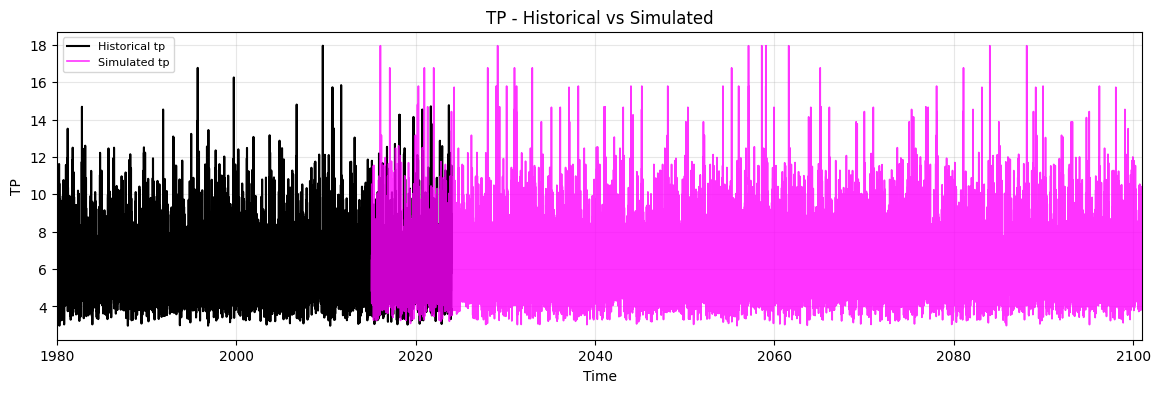

DP: dp_NorthCarolina.nc | target (36.4000, -75.2000) -> nearest site 2964 (36.4000, -75.2000), distance=0.000 km
  historical via src_index=2964 (dp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_dp_Historical_vs_Simulated.png


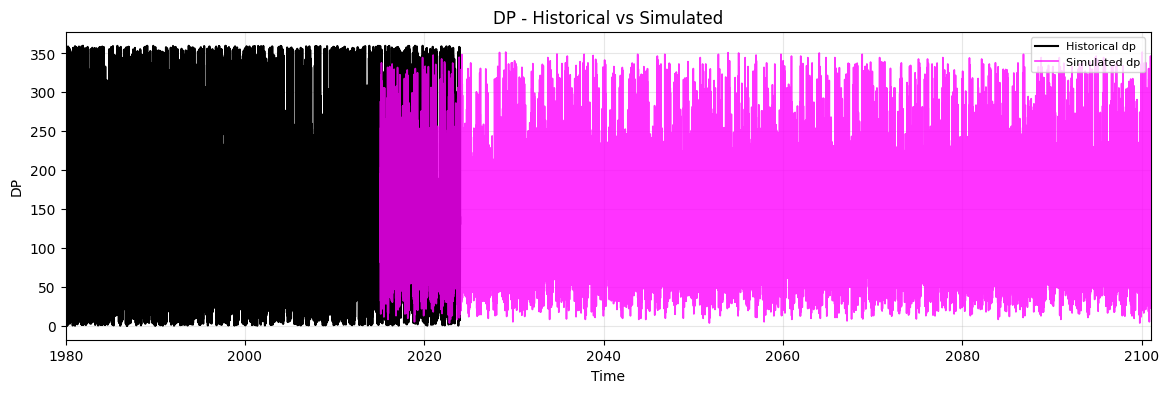

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Histograms_allvars_bulk_random_member.png


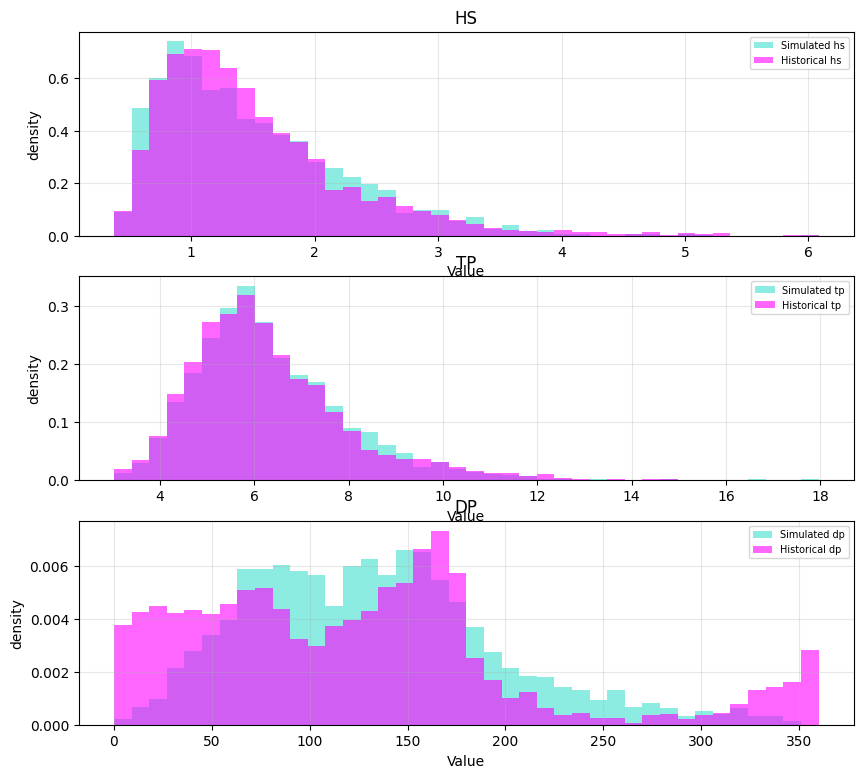

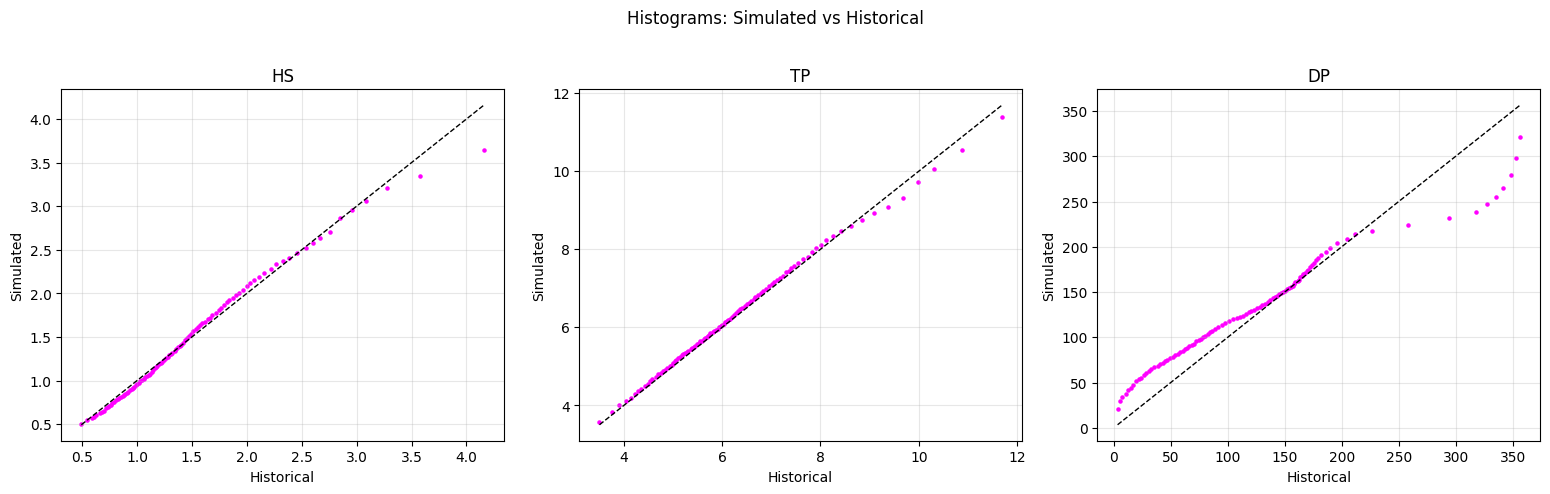

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/QQ_allvars_Historical_vs_Simulated.png


<Figure size 640x480 with 0 Axes>

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_hs_bulk.png


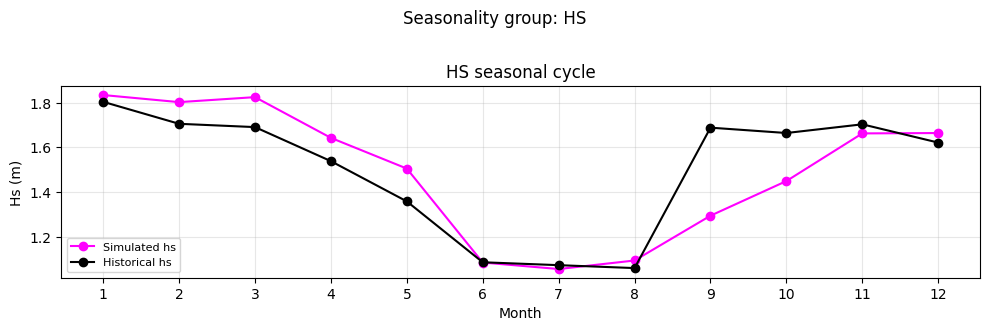

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_tp_bulk.png


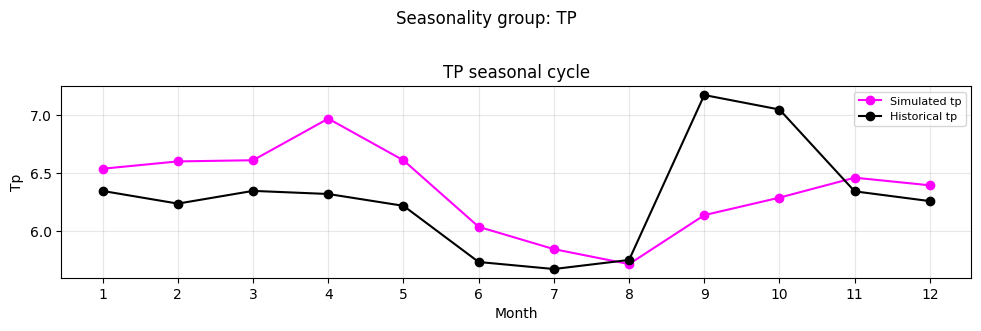

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_dp_bulk.png


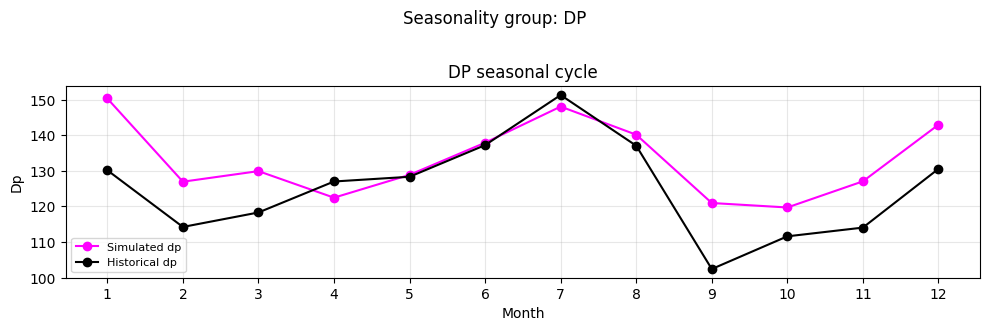

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Scatter_group_level_base_Historical_vs_Simulated_overlap.png


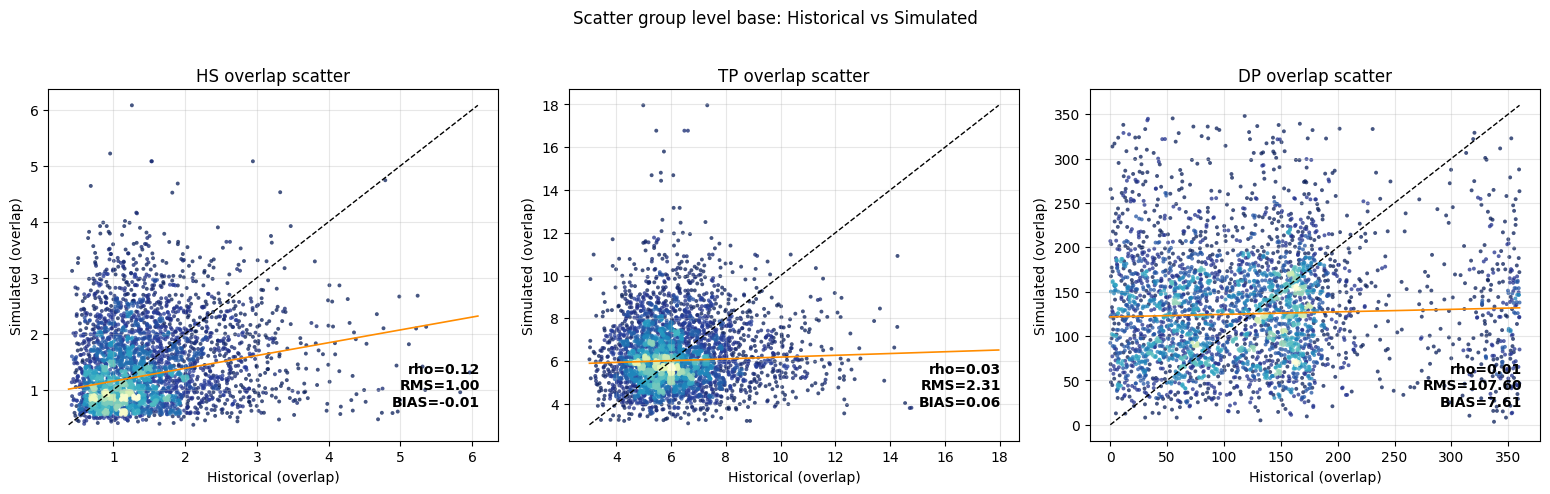

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_timeseries_bulk_vs_emulator.png


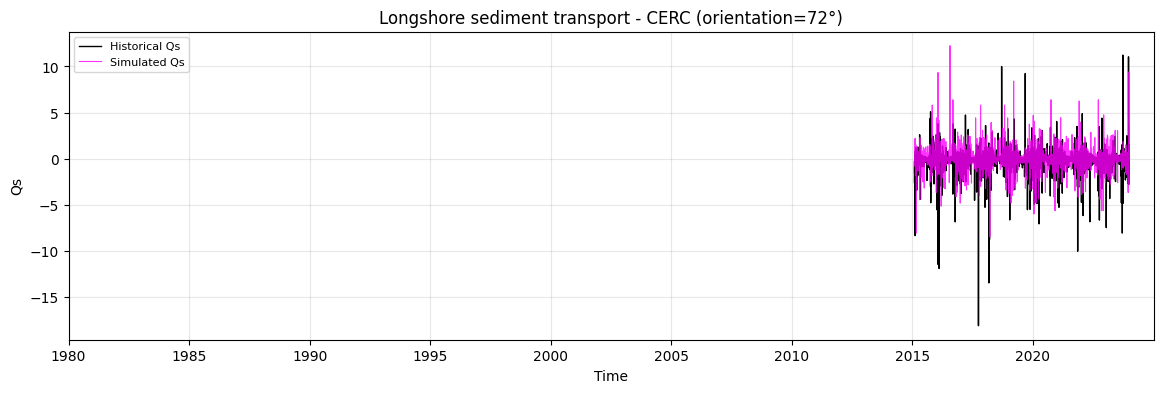

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_cumulative_bulk_vs_emulator.png


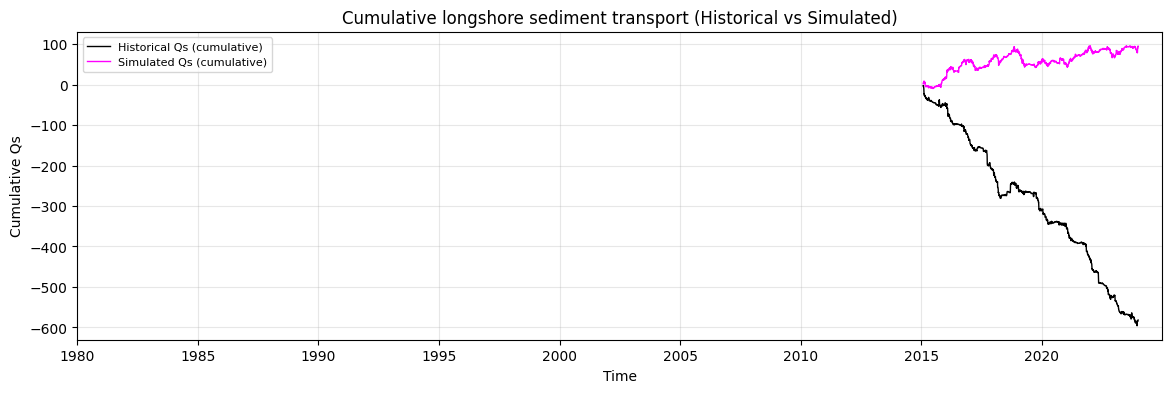

In [28]:
import importlib
importlib.reload(alr_plotting)
daily_pairs, save_folder = alr_plotting.plot_from_folder(
    data_folder="outputs/ipsl_245/OffshorePoints",
    point_lat=36.4,
    point_lon=-75.2,
    variables=["hs", "tp", "dp"],
    historical_folder="../02_Wind_Metamodel/outputs/NorthCarolina",
    shoreline_orientation_deg=72,
    original_band=None,
    plot_non_overlap_timeseries=True,
)


HS: hs_NorthCarolina.nc | target (36.3000, -75.4000) -> nearest site 2963 (36.3000, -75.4000), distance=0.000 km
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Location_map_selected_site.png


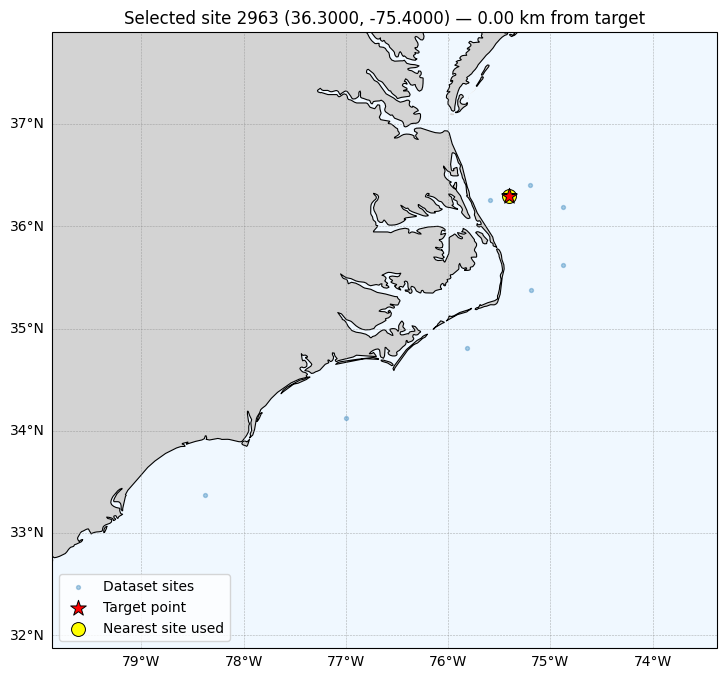

Historical folder: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/02_Wind_Metamodel/outputs/NorthCarolina
  historical via src_index=2963 (hs_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_hs_Historical_vs_Simulated.png


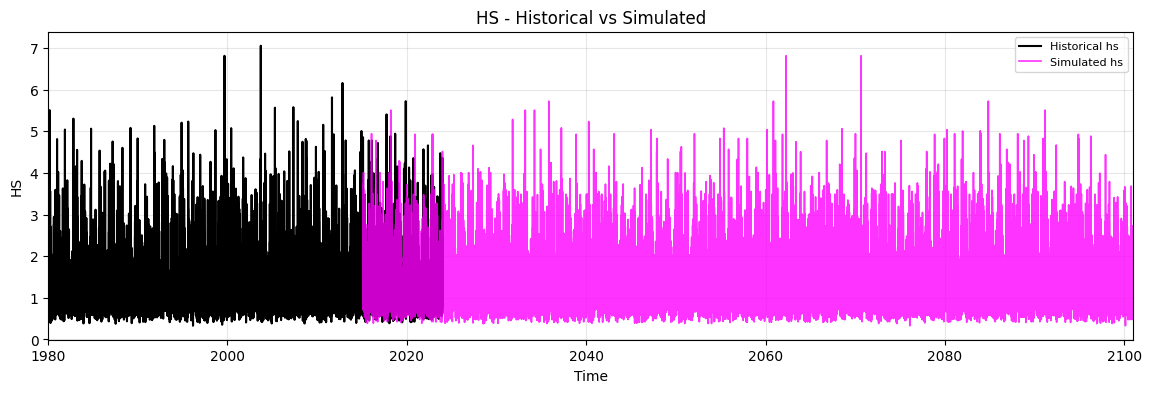

TP: tp_NorthCarolina.nc | target (36.3000, -75.4000) -> nearest site 2963 (36.3000, -75.4000), distance=0.000 km
  historical via src_index=2963 (tp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_tp_Historical_vs_Simulated.png


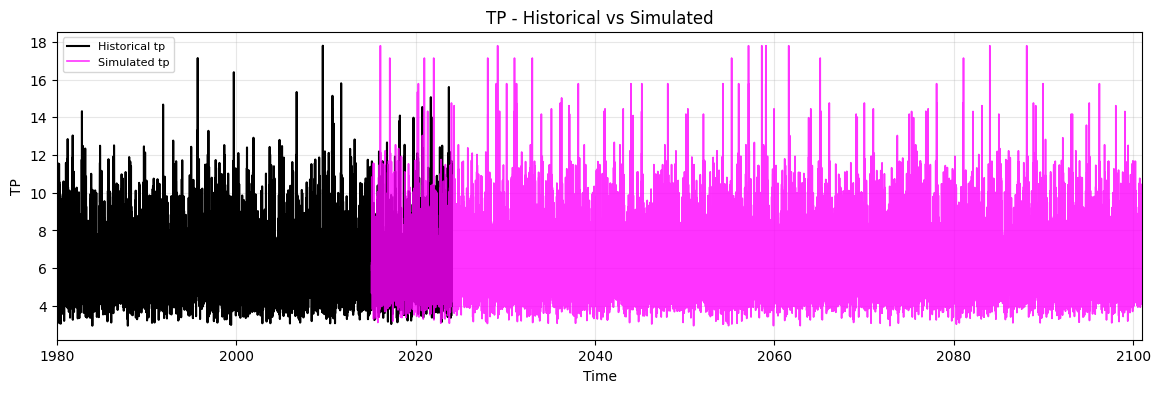

DP: dp_NorthCarolina.nc | target (36.3000, -75.4000) -> nearest site 2963 (36.3000, -75.4000), distance=0.000 km
  historical via src_index=2963 (dp_NorthCarolina.nc)
Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Daily_mean_dp_Historical_vs_Simulated.png


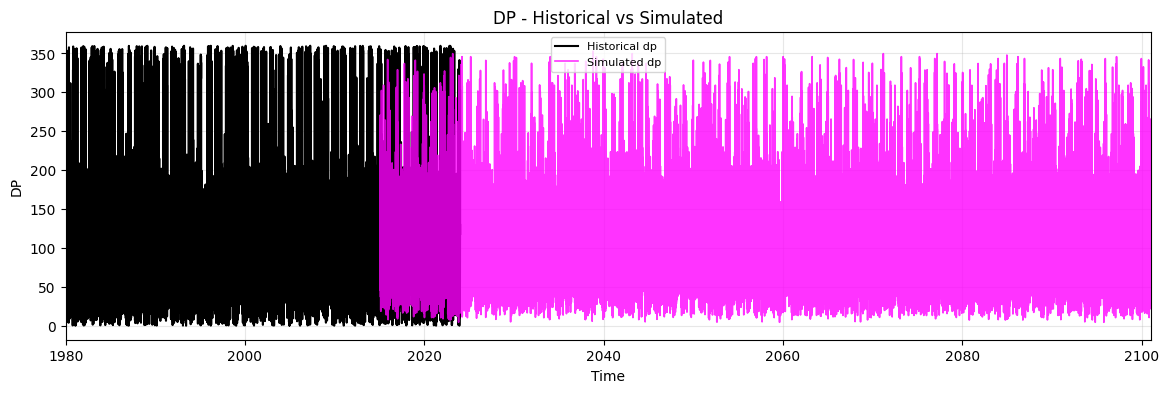

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Histograms_allvars_bulk_random_member.png


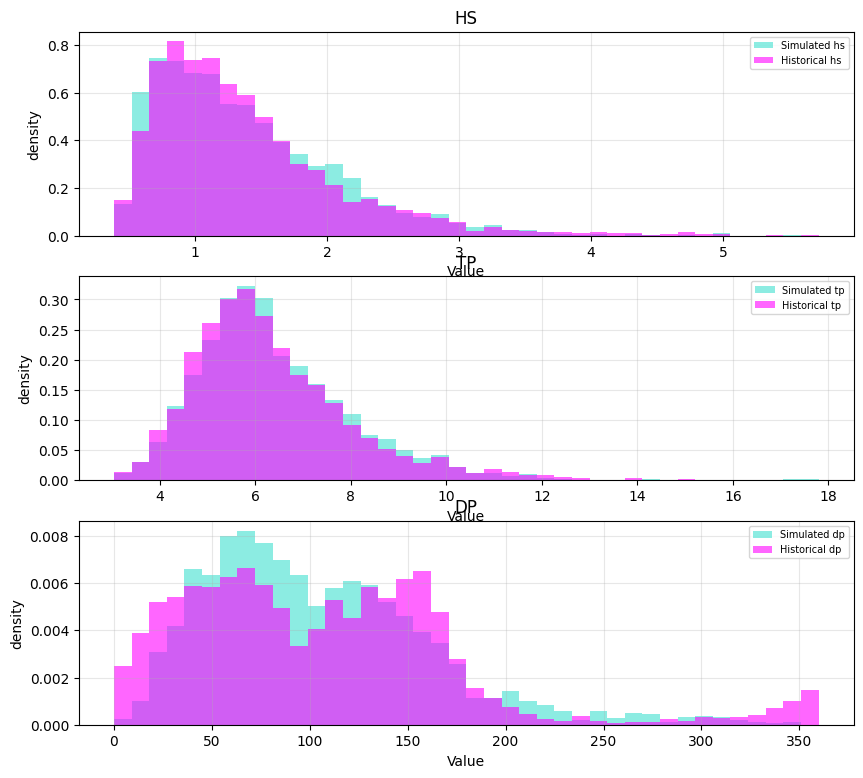

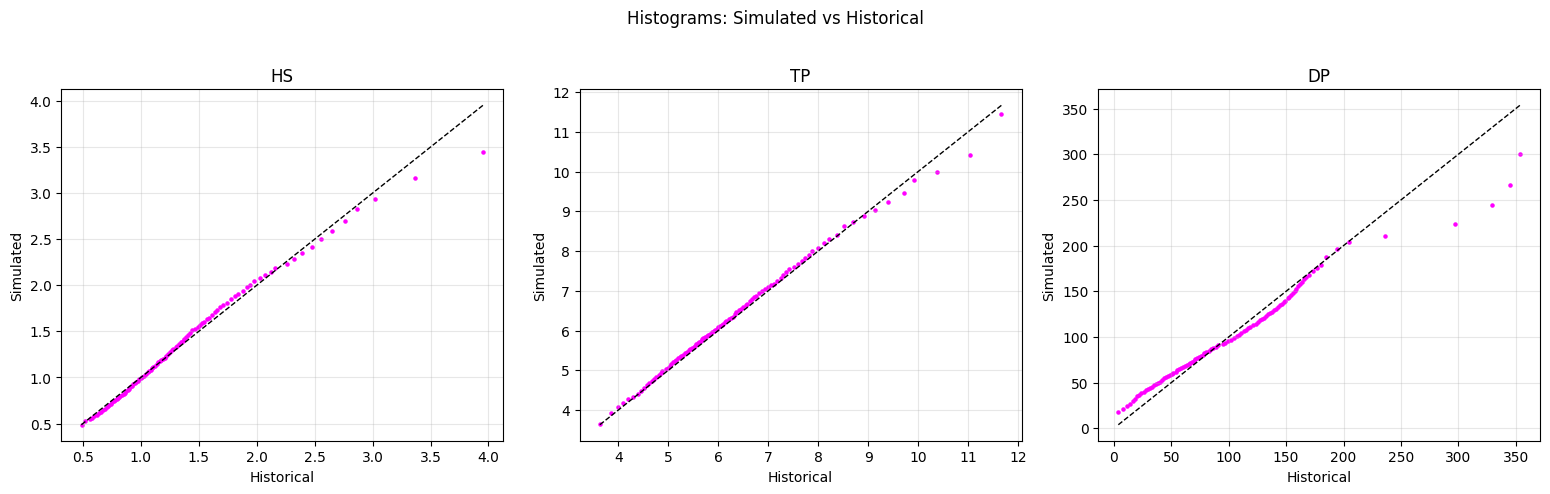

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/QQ_allvars_Historical_vs_Simulated.png


<Figure size 640x480 with 0 Axes>

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_hs_bulk.png


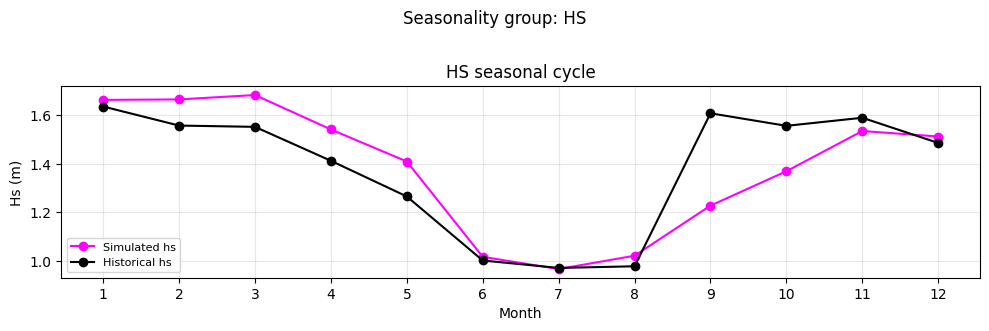

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_tp_bulk.png


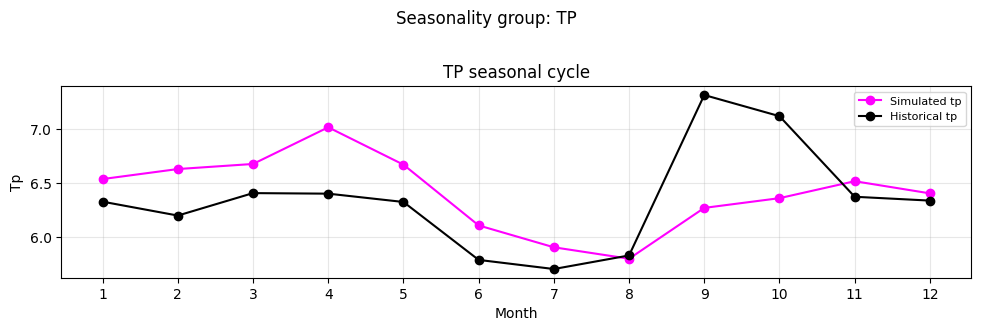

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Seasonal_group_dp_bulk.png


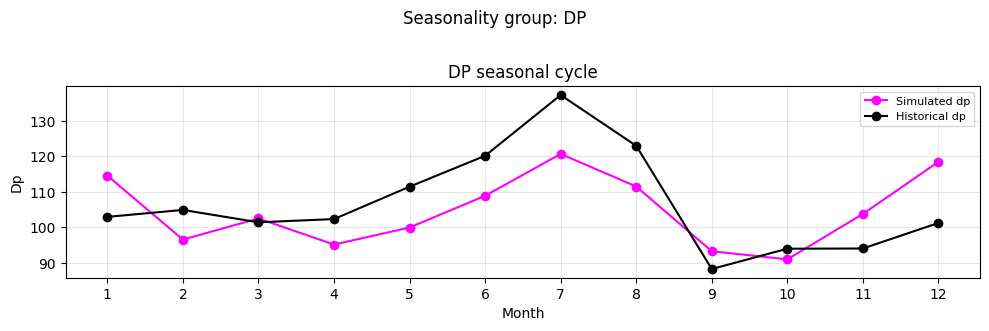

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Scatter_group_level_base_Historical_vs_Simulated_overlap.png


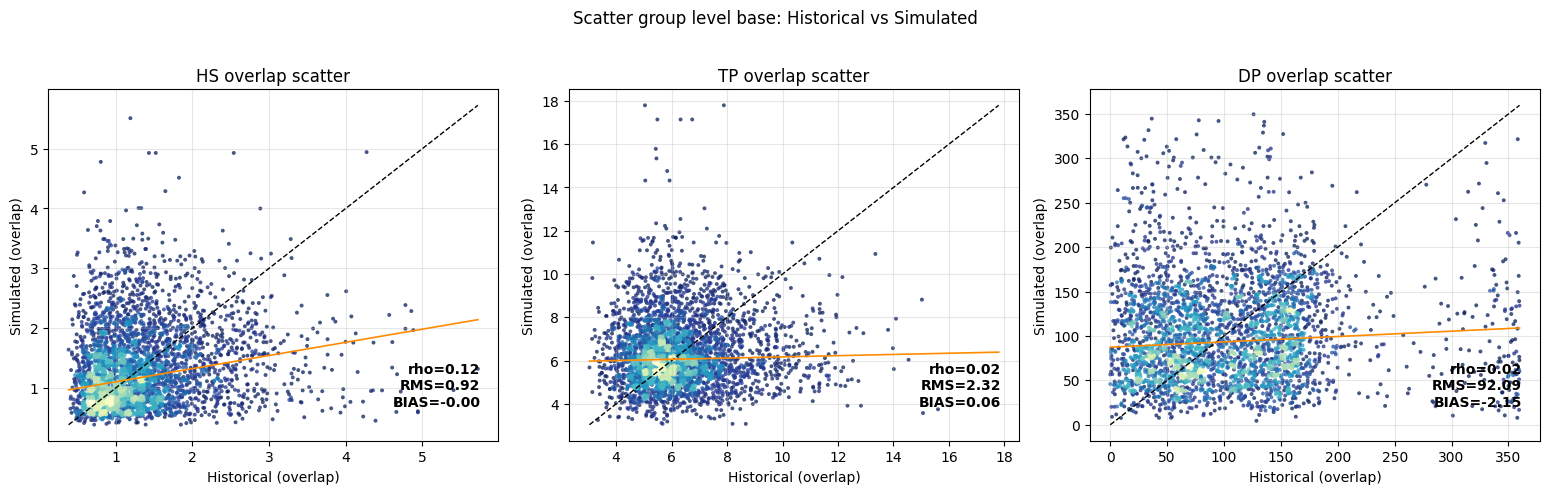

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_timeseries_bulk_vs_emulator.png


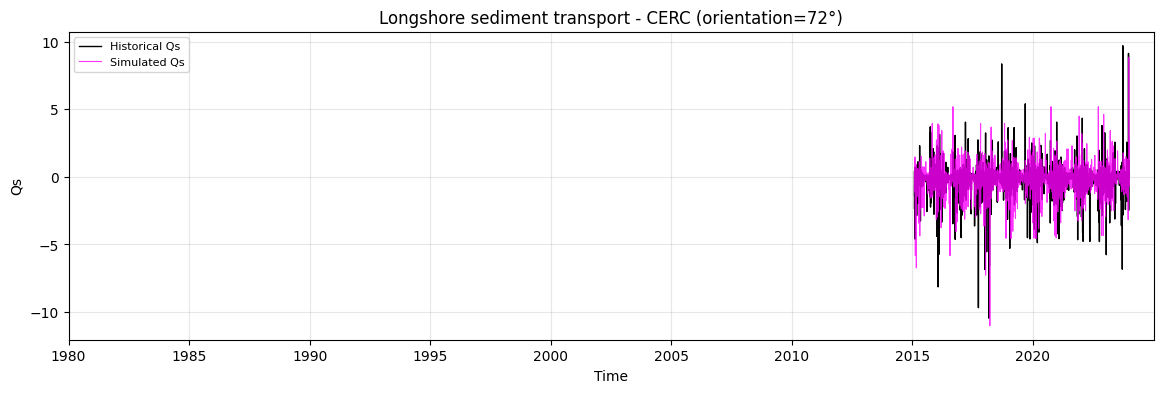

Saved: /lustre/geocean/WORK/users/montanoj/personal/ShoreShop3_2026/03_NC_Wave_Emulator/outputs/Figures/ALR_bulk_bootstrap_month/Qs_cumulative_bulk_vs_emulator.png


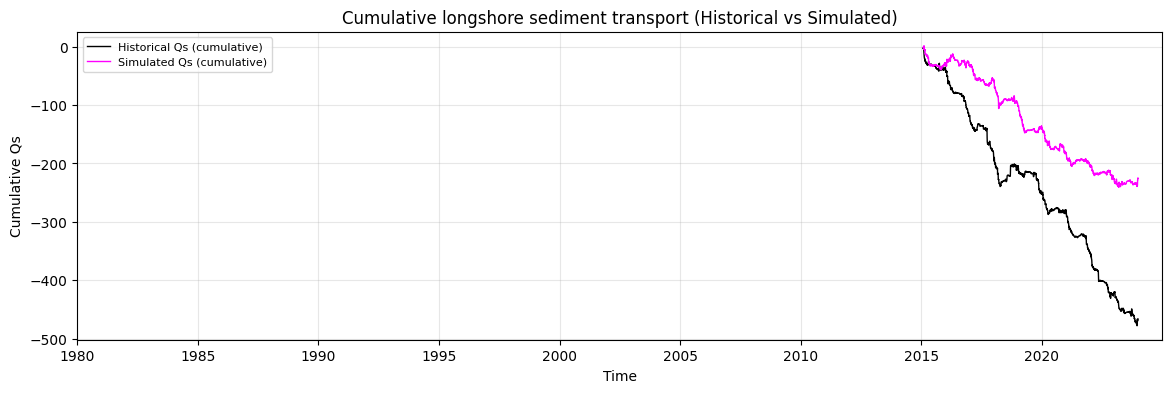

In [29]:
import importlib
importlib.reload(alr_plotting)
daily_pairs, save_folder = alr_plotting.plot_from_folder(
    data_folder="outputs/ipsl_245/OffshorePoints",
    point_lat=36.3,
    point_lon=-75.4,
    variables=["hs", "tp", "dp"],
    historical_folder="../02_Wind_Metamodel/outputs/NorthCarolina",
    shoreline_orientation_deg=72,
    original_band=None,
    plot_non_overlap_timeseries=True,
)
